In [1]:
import sys
import platform

print("Python version:")
print(sys.version)

print("\nPython executable:")
print(sys.executable)

print("\nOperating system:")
print(platform.platform())

Python version:
3.11.15 (main, Jun 11 2026, 15:14:57) [Clang 20.1.8 ]

Python executable:
/opt/miniconda3/envs/cse445-model-training/bin/python

Operating system:
macOS-26.5.1-arm64-arm-64bit


In [3]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

print("Libraries imported successfully.\n")

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Scikit-learn version:", sklearn.__version__)
print("Joblib version:", joblib.__version__)


Libraries imported successfully.

NumPy version: 2.4.6
Pandas version: 3.0.5
Matplotlib version: 3.11.1
Scikit-learn version: 1.9.0
Joblib version: 1.5.3


In [5]:
import pandas as pd

train_path = "train.csv"
val_path = "validation.csv"
test_path = "test.csv"

train_df = pd.read_csv("./train_features.csv")
val_df = pd.read_csv("./validation_features.csv")
test_df = pd.read_csv("./test_features.csv")

print("Datasets loaded successfully.\n")

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Datasets loaded successfully.

Train shape: (15140, 25)
Validation shape: (4321, 25)
Test shape: (2153, 25)


In [6]:
print("TRAIN DATASET FIRST 5 ROWS")
display(train_df.head())

print("\nCOLUMN NAMES")
print(train_df.columns.tolist())

print("\nDATA TYPES")
print(train_df.dtypes)

print("\nVALIDATION FIRST 3 ROWS")
display(val_df.head(3))

print("\nTEST FIRST 3 ROWS")
display(test_df.head(3))

TRAIN DATASET FIRST 5 ROWS


,window_id,filename,subject_id,action_code,label,head_drop,shoulder_drop,head_velocity_mean,head_velocity_max,torso_tilt_std,...,accel_slope,vertical_ratio,max_downward_vel,ending_tilt,tilt_net_change,knee_bend_min,elbow_angle_min,hand_dwell_frames,foot_sep_std,time_to_min_drop
0,134,S001C001P002R001A001.skeleton,2,1,Normal Activity,0.021990,0.025881,0.009765,0.078088,1.989774,...,0.000262,0.363479,0.048212,12.138032,-0.676457,1.616190,51.684314,14,0.013040,0.400000
1,135,S001C001P002R001A001.skeleton,2,1,Normal Activity,0.115696,0.000000,0.010742,0.070687,1.622373,...,-0.000057,0.879545,0.066450,13.362887,-4.745930,1.482432,51.684314,19,0.030064,0.766667
2,136,S001C001P002R001A001.skeleton,2,1,Normal Activity,0.083397,0.006508,0.008980,0.070687,0.597236,...,-0.000364,1.924324,0.066450,12.536761,0.311058,1.482432,65.495301,5,0.022987,0.266667
3,137,S001C002P002R001A001.skeleton,2,1,Normal Activity,0.048274,0.000074,0.009652,0.086235,3.000811,...,0.000660,0.323108,0.027550,4.931233,-7.773790,1.153614,66.096964,0,0.040940,0.966667
4,138,S001C002P002R001A001.skeleton,2,1,Normal Activity,0.051913,0.000000,0.011519,0.086235,2.112499,...,-0.000649,0.556627,0.027550,8.463014,-2.759823,1.086152,61.065162,0,0.036981,0.866667



COLUMN NAMES
['window_id', 'filename', 'subject_id', 'action_code', 'label', 'head_drop', 'shoulder_drop', 'head_velocity_mean', 'head_velocity_max', 'torso_tilt_std', 'torso_tilt_range', 'lateral_sway_range', 'sway_direction_changes', 'min_hand_to_chest', 'hand_to_chest_drop', 'accel_slope', 'vertical_ratio', 'max_downward_vel', 'ending_tilt', 'tilt_net_change', 'knee_bend_min', 'elbow_angle_min', 'hand_dwell_frames', 'foot_sep_std', 'time_to_min_drop']

DATA TYPES
window_id                   int64
filename                      str
subject_id                  int64
action_code                 int64
label                         str
head_drop                 float64
shoulder_drop             float64
head_velocity_mean        float64
head_velocity_max         float64
torso_tilt_std            float64
torso_tilt_range          float64
lateral_sway_range        float64
sway_direction_changes      int64
min_hand_to_chest         float64
hand_to_chest_drop        float64
accel_slope       

,window_id,filename,subject_id,action_code,label,head_drop,shoulder_drop,head_velocity_mean,head_velocity_max,torso_tilt_std,...,accel_slope,vertical_ratio,max_downward_vel,ending_tilt,tilt_net_change,knee_bend_min,elbow_angle_min,hand_dwell_frames,foot_sep_std,time_to_min_drop
0,0,S001C001P001R001A001.skeleton,1,1,Normal Activity,0.013047,0.001229,0.003940,0.013666,0.263809,...,-0.000010,0.787989,0.008955,13.608580,-0.009416,1.462847,77.762369,0,0.021661,0.966667
1,1,S001C001P001R001A001.skeleton,1,1,Normal Activity,0.029074,0.012166,0.007114,0.035483,0.859001,...,0.000312,0.332596,0.009315,15.210333,2.559700,1.466637,50.896758,0,0.030092,0.566667
2,2,S001C001P001R001A001.skeleton,1,1,Normal Activity,0.036005,0.013101,0.010434,0.040967,0.766653,...,0.000100,0.254533,0.039946,15.901945,1.682094,1.466637,35.020852,1,0.023193,0.933333



TEST FIRST 3 ROWS


,window_id,filename,subject_id,action_code,label,head_drop,shoulder_drop,head_velocity_mean,head_velocity_max,torso_tilt_std,...,accel_slope,vertical_ratio,max_downward_vel,ending_tilt,tilt_net_change,knee_bend_min,elbow_angle_min,hand_dwell_frames,foot_sep_std,time_to_min_drop
0,2680,S003C001P018R001A001.skeleton,18,1,Normal Activity,0.088594,0.002010,0.011727,0.117847,0.534232,...,0.001096,0.947405,0.044884,3.348549,-0.605736,1.305033,58.556046,0,0.011554,0.633333
1,2681,S003C001P018R001A001.skeleton,18,1,Normal Activity,0.039634,0.001196,0.012416,0.117847,0.745796,...,-0.000580,0.973693,0.042435,3.418587,-1.162845,1.290814,58.556046,0,0.012898,0.133333
2,2682,S003C001P018R001A001.skeleton,18,1,Normal Activity,0.007168,0.000154,0.004689,0.018411,0.444681,...,-0.000018,0.080065,0.012868,1.936915,-1.519474,1.289524,60.202787,0,0.004708,0.466667


In [7]:
train_subjects = set(train_df["subject_id"].unique())
val_subjects = set(val_df["subject_id"].unique())
test_subjects = set(test_df["subject_id"].unique())

print("Number of train subjects:", len(train_subjects))
print("Number of validation subjects:", len(val_subjects))
print("Number of test subjects:", len(test_subjects))

print("\nTrain subjects:")
print(sorted(train_subjects))

print("\nValidation subjects:")
print(sorted(val_subjects))

print("\nTest subjects:")
print(sorted(test_subjects))

print("\nSubject overlap checks:")
print("Train ∩ Validation:", train_subjects.intersection(val_subjects))
print("Train ∩ Test:", train_subjects.intersection(test_subjects))
print("Validation ∩ Test:", val_subjects.intersection(test_subjects))

Number of train subjects: 28
Number of validation subjects: 8
Number of test subjects: 4

Train subjects:
[np.int64(2), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(20), np.int64(22), np.int64(23), np.int64(24), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(34), np.int64(35), np.int64(36), np.int64(38), np.int64(40)]

Validation subjects:
[np.int64(1), np.int64(3), np.int64(11), np.int64(21), np.int64(25), np.int64(28), np.int64(33), np.int64(39)]

Test subjects:
[np.int64(18), np.int64(26), np.int64(27), np.int64(37)]

Subject overlap checks:
Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()


In [8]:
metadata_cols = [
    "window_id",
    "filename",
    "subject_id",
    "action_code",
    "label"
]

feature_cols = [
    col for col in train_df.columns
    if col not in metadata_cols
]

print("Number of feature columns:", len(feature_cols))

print("\nFeature columns:")
for i, col in enumerate(feature_cols, start=1):
    print(f"{i}. {col}")

print("\nMetadata columns:")
for col in metadata_cols:
    print(col)

print("\nFeature consistency checks:")
print("Train feature count:", len([c for c in train_df.columns if c not in metadata_cols]))
print("Validation feature count:", len([c for c in val_df.columns if c not in metadata_cols]))
print("Test feature count:", len([c for c in test_df.columns if c not in metadata_cols]))

print("\nSame feature order in all datasets:")
print(
    feature_cols ==
    [c for c in val_df.columns if c not in metadata_cols] ==
    [c for c in test_df.columns if c not in metadata_cols]
)

Number of feature columns: 20

Feature columns:
1. head_drop
2. shoulder_drop
3. head_velocity_mean
4. head_velocity_max
5. torso_tilt_std
6. torso_tilt_range
7. lateral_sway_range
8. sway_direction_changes
9. min_hand_to_chest
10. hand_to_chest_drop
11. accel_slope
12. vertical_ratio
13. max_downward_vel
14. ending_tilt
15. tilt_net_change
16. knee_bend_min
17. elbow_angle_min
18. hand_dwell_frames
19. foot_sep_std
20. time_to_min_drop

Metadata columns:
window_id
filename
subject_id
action_code
label

Feature consistency checks:
Train feature count: 20
Validation feature count: 20
Test feature count: 20

Same feature order in all datasets:
True


In [9]:
import numpy as np

print("MISSING VALUES")
print("Train:", train_df[feature_cols].isna().sum().sum())
print("Validation:", val_df[feature_cols].isna().sum().sum())
print("Test:", test_df[feature_cols].isna().sum().sum())

print("\nINFINITE VALUES")
print(
    "Train:",
    np.isinf(train_df[feature_cols].to_numpy()).sum()
)
print(
    "Validation:",
    np.isinf(val_df[feature_cols].to_numpy()).sum()
)
print(
    "Test:",
    np.isinf(test_df[feature_cols].to_numpy()).sum()
)

print("\nDUPLICATE FULL ROWS")
print("Train:", train_df.duplicated().sum())
print("Validation:", val_df.duplicated().sum())
print("Test:", test_df.duplicated().sum())

print("\nNON-NUMERIC FEATURE COLUMNS")
print(
    train_df[feature_cols]
    .select_dtypes(exclude=np.number)
    .columns.tolist()
)

print("\nFEATURE VALUE SUMMARY")
display(train_df[feature_cols].describe().T)

MISSING VALUES
Train: 0
Validation: 0
Test: 0

INFINITE VALUES
Train: 0
Validation: 0
Test: 0

DUPLICATE FULL ROWS
Train: 0
Validation: 0
Test: 0

NON-NUMERIC FEATURE COLUMNS
[]

FEATURE VALUE SUMMARY


,count,mean,std,min,25%,50%,75%,max
head_drop,15140.0,0.202012,0.258443,0.000000,0.026013,0.095938,0.287042,2.142086
shoulder_drop,15140.0,0.117809,0.182852,0.000000,0.004827,0.034793,0.155437,1.741886
head_velocity_mean,15140.0,0.046069,0.046742,0.000858,0.015719,0.034924,0.062051,0.933099
head_velocity_max,15140.0,0.175932,0.220877,0.001832,0.057122,0.121382,0.212578,8.916353
torso_tilt_std,15140.0,5.666517,5.456960,0.039879,1.409624,3.783281,8.599951,44.052395
torso_tilt_range,15140.0,18.720649,17.028715,0.124671,5.096255,13.438661,28.097156,138.676615
lateral_sway_range,15140.0,0.247306,0.223946,0.002374,0.075727,0.179817,0.356441,1.790971
sway_direction_changes,15140.0,10.780449,4.077752,0.000000,8.000000,11.000000,14.000000,26.000000
min_hand_to_chest,15140.0,0.478791,0.168194,0.011360,0.355697,0.485135,0.604021,2.903849
hand_to_chest_drop,15140.0,0.126688,0.138192,0.000000,0.022998,0.084453,0.187022,3.003497


In [10]:
def show_class_distribution(df, name):
    counts = df["label"].value_counts()
    percentages = df["label"].value_counts(normalize=True) * 100

    result = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages.round(2)
    })

    print(f"\n{name} CLASS DISTRIBUTION")
    display(result)


show_class_distribution(train_df, "TRAIN")
show_class_distribution(val_df, "VALIDATION")
show_class_distribution(test_df, "TEST")


TRAIN CLASS DISTRIBUTION


,Count,Percentage
label,,
Normal Activity,7185,47.46
Staggering/Unbalanced Movement,3684,24.33
Touch Chest,2425,16.02
Falling Down,1846,12.19



VALIDATION CLASS DISTRIBUTION


,Count,Percentage
label,,
Normal Activity,2060,47.67
Staggering/Unbalanced Movement,1052,24.35
Touch Chest,684,15.83
Falling Down,525,12.15



TEST CLASS DISTRIBUTION


,Count,Percentage
label,,
Normal Activity,1030,47.84
Staggering/Unbalanced Movement,510,23.69
Touch Chest,346,16.07
Falling Down,267,12.40


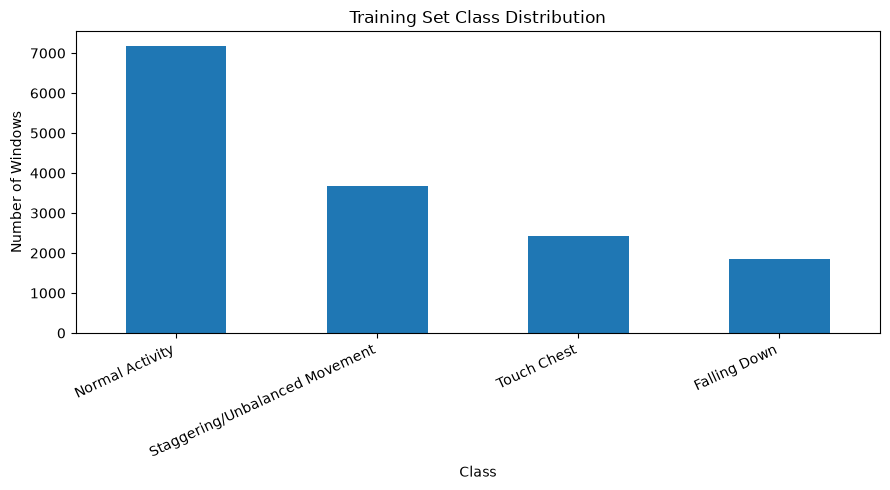

In [11]:
train_counts = train_df["label"].value_counts()

plt.figure(figsize=(9, 5))
train_counts.plot(kind="bar")

plt.title("Training Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Windows")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

In [12]:
X_train = train_df[feature_cols].copy()
y_train = train_df["label"].copy()

X_val = val_df[feature_cols].copy()
y_val = val_df["label"].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df["label"].copy()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nX_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

print("\nX_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nTraining labels:")
print(sorted(y_train.unique()))

print("\nValidation labels match training:")
print(set(y_val.unique()) == set(y_train.unique()))

print("Test labels match training:")
print(set(y_test.unique()) == set(y_train.unique()))

X_train shape: (15140, 20)
y_train shape: (15140,)

X_val shape: (4321, 20)
y_val shape: (4321,)

X_test shape: (2153, 20)
y_test shape: (2153,)

Training labels:
['Falling Down', 'Normal Activity', 'Staggering/Unbalanced Movement', 'Touch Chest']

Validation labels match training:
True
Test labels match training:
True


In [13]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print("Calculated class weights:\n")

for class_name, weight in class_weights.items():
    print(f"{class_name}: {weight:.4f}")

Calculated class weights:

Falling Down: 2.0504
Normal Activity: 0.5268
Staggering/Unbalanced Movement: 1.0274
Touch Chest: 1.5608


In [14]:
from sklearn.ensemble import RandomForestClassifier
import time

rf_baseline = RandomForestClassifier(
    n_estimators=300,
    bootstrap=True,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

rf_baseline.fit(X_train, y_train)

end_time = time.time()

print("Baseline Random Forest trained successfully.")
print(f"Training time: {end_time - start_time:.2f} seconds")

print("\nImportant RF settings:")
print("Number of trees:", rf_baseline.n_estimators)
print("Bootstrap enabled:", rf_baseline.bootstrap)
print("Max features:", rf_baseline.max_features)
print("Class weight:", rf_baseline.class_weight)

Baseline Random Forest trained successfully.
Training time: 1.30 seconds

Important RF settings:
Number of trees: 300
Bootstrap enabled: True
Max features: sqrt
Class weight: balanced


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd

# Different numbers of variables/features to try at each split
mtry_values = [2, 3, 4, 5, 7, 10]

mtry_results = []

for mtry in mtry_values:

    rf = RandomForestClassifier(
        n_estimators=300,
        max_features=mtry,          # replaces max_features="sqrt"
        bootstrap=True,             # keeps bagging enabled
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    # Train the Random Forest
    rf.fit(X_train, y_train)

    # Predict on validation data
    val_pred = rf.predict(X_val)

    # Calculate validation metrics
    accuracy = accuracy_score(y_val, val_pred)
    balanced_acc = balanced_accuracy_score(y_val, val_pred)

    precision = precision_score(
        y_val,
        val_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_val,
        val_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_val,
        val_pred,
        average="macro",
        zero_division=0
    )

    mtry_results.append({
        "max_features": mtry,
        "Accuracy": accuracy,
        "Balanced Accuracy": balanced_acc,
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1": macro_f1
    })

# Convert results to a table
mtry_results_df = pd.DataFrame(mtry_results)

# Sort from best Macro F1 to worst
mtry_results_df = mtry_results_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

display(mtry_results_df)

,max_features,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
0,3,0.734321,0.703255,0.694834,0.703255,0.697624
1,2,0.734321,0.701342,0.695682,0.701342,0.697048
2,5,0.733395,0.702839,0.690822,0.702839,0.695203
3,4,0.733395,0.701525,0.690731,0.701525,0.694480
4,7,0.728304,0.697726,0.684931,0.697726,0.689763
5,10,0.726684,0.699017,0.682469,0.699017,0.688999


In [16]:
from sklearn.ensemble import RandomForestClassifier
import time

rf_selected = RandomForestClassifier(
    n_estimators=300,
    max_features=3,
    bootstrap=True,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

rf_selected.fit(X_train, y_train)

end_time = time.time()

print("Selected Random Forest trained successfully.")
print(f"Training time: {end_time - start_time:.2f} seconds")

print("\nSelected settings:")
print("Number of trees:", rf_selected.n_estimators)
print("max_features (mtry):", rf_selected.max_features)
print("Bootstrap enabled:", rf_selected.bootstrap)
print("Class weight:", rf_selected.class_weight)

Selected Random Forest trained successfully.
Training time: 1.05 seconds

Selected settings:
Number of trees: 300
max_features (mtry): 3
Bootstrap enabled: True
Class weight: balanced


In [17]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    classification_report,
    confusion_matrix
)

# Predict on validation set
rf_val_pred = rf_selected.predict(X_val)

# Overall metrics
rf_val_accuracy = accuracy_score(y_val, rf_val_pred)
rf_val_balanced_acc = balanced_accuracy_score(y_val, rf_val_pred)
rf_val_macro_precision = precision_score(
    y_val, rf_val_pred, average="macro", zero_division=0
)
rf_val_macro_recall = recall_score(
    y_val, rf_val_pred, average="macro", zero_division=0
)
rf_val_macro_f1 = f1_score(
    y_val, rf_val_pred, average="macro", zero_division=0
)
rf_val_weighted_f1 = f1_score(
    y_val, rf_val_pred, average="weighted", zero_division=0
)
rf_val_mcc = matthews_corrcoef(y_val, rf_val_pred)
rf_val_kappa = cohen_kappa_score(y_val, rf_val_pred)

print("RANDOM FOREST VALIDATION RESULTS")
print()

print(f"Accuracy:           {rf_val_accuracy:.4f}")
print(f"Balanced Accuracy:  {rf_val_balanced_acc:.4f}")
print(f"Macro Precision:    {rf_val_macro_precision:.4f}")
print(f"Macro Recall:       {rf_val_macro_recall:.4f}")
print(f"Macro F1:           {rf_val_macro_f1:.4f}")
print(f"Weighted F1:        {rf_val_weighted_f1:.4f}")
print(f"MCC:                {rf_val_mcc:.4f}")
print(f"Cohen's Kappa:      {rf_val_kappa:.4f}")

print("\nCLASSIFICATION REPORT")
print(
    classification_report(
        y_val,
        rf_val_pred,
        digits=4,
        zero_division=0
    )
)

RANDOM FOREST VALIDATION RESULTS

Accuracy:           0.7343
Balanced Accuracy:  0.7033
Macro Precision:    0.6948
Macro Recall:       0.7033
Macro F1:           0.6976
Weighted F1:        0.7344
MCC:                0.6080
Cohen's Kappa:      0.6076

CLASSIFICATION REPORT
                                precision    recall  f1-score   support

                  Falling Down     0.5810    0.6762    0.6250       525
               Normal Activity     0.7925    0.7748    0.7835      2060
Staggering/Unbalanced Movement     0.7664    0.7890    0.7775      1052
                   Touch Chest     0.6395    0.5731    0.6045       684

                      accuracy                         0.7343      4321
                     macro avg     0.6948    0.7033    0.6976      4321
                  weighted avg     0.7362    0.7343    0.7344      4321



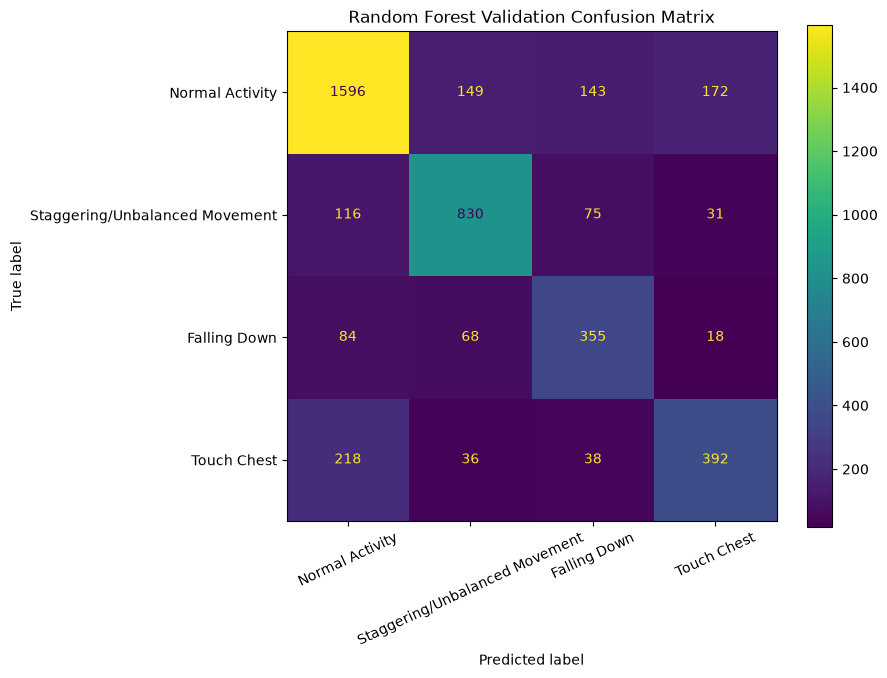

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

class_order = [
    "Normal Activity",
    "Staggering/Unbalanced Movement",
    "Falling Down",
    "Touch Chest"
]

cm = confusion_matrix(
    y_val,
    rf_val_pred,
    labels=class_order
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_order
)

fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(
    ax=ax,
    values_format="d",
    xticks_rotation=25
)

plt.title("Random Forest Validation Confusion Matrix")
plt.tight_layout()
plt.show()

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd
import time

rf_param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [None, 15, 25],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2, 4]
}

rf_tuning_results = []

start_time = time.time()

for params in ParameterGrid(rf_param_grid):

    rf = RandomForestClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_split=params["min_samples_split"],
        min_samples_leaf=params["min_samples_leaf"],
        max_features=3,
        bootstrap=True,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    val_pred = rf.predict(X_val)

    accuracy = accuracy_score(y_val, val_pred)
    balanced_acc = balanced_accuracy_score(y_val, val_pred)

    macro_precision = precision_score(
        y_val,
        val_pred,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_val,
        val_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_val,
        val_pred,
        average="macro",
        zero_division=0
    )

    falling_recall = recall_score(
        y_val == "Falling Down",
        val_pred == "Falling Down",
        zero_division=0
    )

    touch_recall = recall_score(
        y_val == "Touch Chest",
        val_pred == "Touch Chest",
        zero_division=0
    )

    rf_tuning_results.append({
        **params,
        "Accuracy": accuracy,
        "Balanced Accuracy": balanced_acc,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Falling Recall": falling_recall,
        "Touch Chest Recall": touch_recall
    })

rf_tuning_df = pd.DataFrame(rf_tuning_results)

rf_tuning_df = rf_tuning_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

print(f"Tuning completed in {time.time() - start_time:.2f} seconds")

display(rf_tuning_df.head(10))

Tuning completed in 50.28 seconds


,max_depth,min_samples_leaf,min_samples_split,n_estimators,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Falling Recall,Touch Chest Recall
0,NaN,1,2,500,0.735709,0.702785,0.695795,0.702785,0.697882,0.668571,0.571637
1,NaN,1,2,300,0.734321,0.703255,0.694834,0.703255,0.697624,0.676190,0.573099
2,25.0,1,2,500,0.734321,0.702522,0.693824,0.702522,0.696701,0.672381,0.570175
3,NaN,2,5,300,0.731312,0.710372,0.688618,0.710372,0.696541,0.708571,0.586257
4,NaN,2,2,300,0.730618,0.708594,0.688403,0.708594,0.696076,0.699048,0.587719
5,25.0,1,2,300,0.733164,0.701777,0.693266,0.701777,0.695785,0.676190,0.565789
6,NaN,1,5,300,0.731544,0.706789,0.689268,0.706789,0.695676,0.695238,0.578947
7,NaN,1,5,500,0.732006,0.706188,0.688996,0.706188,0.695415,0.689524,0.577485
8,15.0,2,2,300,0.729692,0.711663,0.686040,0.711663,0.695328,0.716190,0.589181
9,15.0,1,2,500,0.729924,0.706393,0.686983,0.706393,0.694330,0.699048,0.576023


In [20]:
from sklearn.ensemble import RandomForestClassifier
import time

rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features=3,
    bootstrap=True,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

rf_tuned.fit(X_train, y_train)

training_time = time.time() - start_time

print("Tuned Random Forest trained successfully.")
print(f"Training time: {training_time:.2f} seconds")

print("\nFinal tuned RF settings:")
print("Number of trees:", rf_tuned.n_estimators)
print("Max depth:", rf_tuned.max_depth)
print("Minimum samples split:", rf_tuned.min_samples_split)
print("Minimum samples leaf:", rf_tuned.min_samples_leaf)
print("max_features (mtry):", rf_tuned.max_features)
print("Bootstrap / bagging:", rf_tuned.bootstrap)
print("Class weight:", rf_tuned.class_weight)

Tuned Random Forest trained successfully.
Training time: 0.98 seconds

Final tuned RF settings:
Number of trees: 300
Max depth: 15
Minimum samples split: 2
Minimum samples leaf: 2
max_features (mtry): 3
Bootstrap / bagging: True
Class weight: balanced


In [21]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    classification_report
)

rf_tuned_val_pred = rf_tuned.predict(X_val)

accuracy = accuracy_score(y_val, rf_tuned_val_pred)
balanced_acc = balanced_accuracy_score(y_val, rf_tuned_val_pred)

macro_precision = precision_score(
    y_val,
    rf_tuned_val_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_val,
    rf_tuned_val_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_val,
    rf_tuned_val_pred,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_val,
    rf_tuned_val_pred,
    average="weighted",
    zero_division=0
)

mcc = matthews_corrcoef(
    y_val,
    rf_tuned_val_pred
)

kappa = cohen_kappa_score(
    y_val,
    rf_tuned_val_pred
)

print("TUNED RANDOM FOREST VALIDATION RESULTS\n")

print(f"Accuracy:           {accuracy:.4f}")
print(f"Balanced Accuracy:  {balanced_acc:.4f}")
print(f"Macro Precision:    {macro_precision:.4f}")
print(f"Macro Recall:       {macro_recall:.4f}")
print(f"Macro F1:           {macro_f1:.4f}")
print(f"Weighted F1:        {weighted_f1:.4f}")
print(f"MCC:                {mcc:.4f}")
print(f"Cohen's Kappa:      {kappa:.4f}")

print("\nCLASSIFICATION REPORT")

print(
    classification_report(
        y_val,
        rf_tuned_val_pred,
        digits=4,
        zero_division=0
    )
)

TUNED RANDOM FOREST VALIDATION RESULTS

Accuracy:           0.7297
Balanced Accuracy:  0.7117
Macro Precision:    0.6860
Macro Recall:       0.7117
Macro F1:           0.6953
Weighted F1:        0.7321
MCC:                0.6080
Cohen's Kappa:      0.6065

CLASSIFICATION REPORT
                                precision    recall  f1-score   support

                  Falling Down     0.5426    0.7162    0.6174       525
               Normal Activity     0.8146    0.7466    0.7791      2060
Staggering/Unbalanced Movement     0.7670    0.7947    0.7806      1052
                   Touch Chest     0.6200    0.5892    0.6042       684

                      accuracy                         0.7297      4321
                     macro avg     0.6860    0.7117    0.6953      4321
                  weighted avg     0.7392    0.7297    0.7321      4321



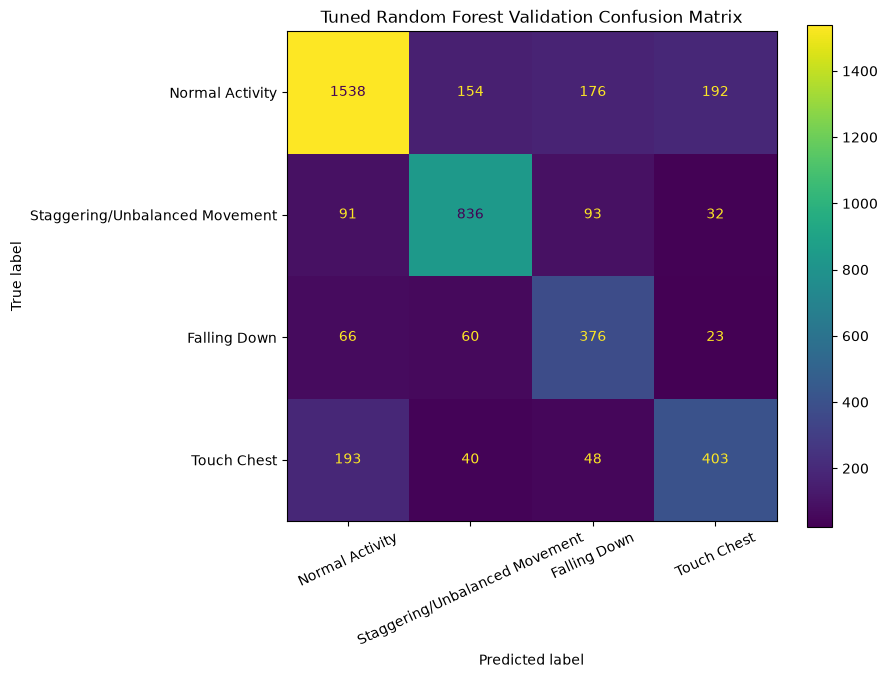

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_order = [
    "Normal Activity",
    "Staggering/Unbalanced Movement",
    "Falling Down",
    "Touch Chest"
]

rf_tuned_cm = confusion_matrix(
    y_val,
    rf_tuned_val_pred,
    labels=class_order
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_tuned_cm,
    display_labels=class_order
)

fig, ax = plt.subplots(figsize=(9, 7))

disp.plot(
    ax=ax,
    values_format="d",
    xticks_rotation=25
)

plt.title("Tuned Random Forest Validation Confusion Matrix")
plt.tight_layout()
plt.show()

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
import time

base_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        random_state=42
    ))
])

svm_baseline = CalibratedClassifierCV(
    estimator=base_svm,
    method="sigmoid",
    cv=5,
    ensemble=False
)

start_time = time.time()

svm_baseline.fit(X_train, y_train)

training_time = time.time() - start_time

print("Calibrated baseline RBF-SVM trained successfully.")
print(f"Training time: {training_time:.2f} seconds")

print("\nSVM settings:")
print("Kernel: RBF")
print("C: 1.0")
print("Gamma: scale")
print("Class weight: balanced")
print("Probability calibration: sigmoid")
print("Calibration folds: 5")

Calibrated baseline RBF-SVM trained successfully.
Training time: 15.20 seconds

SVM settings:
Kernel: RBF
C: 1.0
Gamma: scale
Class weight: balanced
Probability calibration: sigmoid
Calibration folds: 5


In [26]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    classification_report
)

svm_val_pred = svm_baseline.predict(X_val)

svm_accuracy = accuracy_score(y_val, svm_val_pred)
svm_balanced_acc = balanced_accuracy_score(y_val, svm_val_pred)

svm_macro_precision = precision_score(
    y_val,
    svm_val_pred,
    average="macro",
    zero_division=0
)

svm_macro_recall = recall_score(
    y_val,
    svm_val_pred,
    average="macro",
    zero_division=0
)

svm_macro_f1 = f1_score(
    y_val,
    svm_val_pred,
    average="macro",
    zero_division=0
)

svm_weighted_f1 = f1_score(
    y_val,
    svm_val_pred,
    average="weighted",
    zero_division=0
)

svm_mcc = matthews_corrcoef(
    y_val,
    svm_val_pred
)

svm_kappa = cohen_kappa_score(
    y_val,
    svm_val_pred
)

print("BASELINE RBF-SVM VALIDATION RESULTS\n")

print(f"Accuracy:           {svm_accuracy:.4f}")
print(f"Balanced Accuracy:  {svm_balanced_acc:.4f}")
print(f"Macro Precision:    {svm_macro_precision:.4f}")
print(f"Macro Recall:       {svm_macro_recall:.4f}")
print(f"Macro F1:           {svm_macro_f1:.4f}")
print(f"Weighted F1:        {svm_weighted_f1:.4f}")
print(f"MCC:                {svm_mcc:.4f}")
print(f"Cohen's Kappa:      {svm_kappa:.4f}")

print("\nCLASSIFICATION REPORT")

print(
    classification_report(
        y_val,
        svm_val_pred,
        digits=4,
        zero_division=0
    )
)

BASELINE RBF-SVM VALIDATION RESULTS

Accuracy:           0.7299
Balanced Accuracy:  0.7341
Macro Precision:    0.6900
Macro Recall:       0.7341
Macro F1:           0.7051
Weighted F1:        0.7349
MCC:                0.6165
Cohen's Kappa:      0.6128

CLASSIFICATION REPORT
                                precision    recall  f1-score   support

                  Falling Down     0.5473    0.7829    0.6442       525
               Normal Activity     0.8356    0.7180    0.7723      2060
Staggering/Unbalanced Movement     0.7879    0.7662    0.7769      1052
                   Touch Chest     0.5894    0.6696    0.6270       684

                      accuracy                         0.7299      4321
                     macro avg     0.6900    0.7341    0.7051      4321
                  weighted avg     0.7500    0.7299    0.7349      4321



In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd
import time

C_values = [0.5, 1, 2, 5, 10]
gamma_values = ["scale", 0.01, 0.05, 0.1]

svm_tuning_results = []

start_time = time.time()

for C_value in C_values:
    for gamma_value in gamma_values:

        base_svm = Pipeline([
            ("scaler", StandardScaler()),
            ("svm", SVC(
                kernel="rbf",
                C=C_value,
                gamma=gamma_value,
                class_weight="balanced",
                random_state=42
            ))
        ])

        calibrated_svm = CalibratedClassifierCV(
            estimator=base_svm,
            method="sigmoid",
            cv=5,
            ensemble=False
        )

        calibrated_svm.fit(X_train, y_train)

        val_pred = calibrated_svm.predict(X_val)

        accuracy = accuracy_score(y_val, val_pred)
        balanced_acc = balanced_accuracy_score(y_val, val_pred)

        macro_precision = precision_score(
            y_val,
            val_pred,
            average="macro",
            zero_division=0
        )

        macro_recall = recall_score(
            y_val,
            val_pred,
            average="macro",
            zero_division=0
        )

        macro_f1 = f1_score(
            y_val,
            val_pred,
            average="macro",
            zero_division=0
        )

        falling_recall = recall_score(
            y_val == "Falling Down",
            val_pred == "Falling Down",
            zero_division=0
        )

        touch_recall = recall_score(
            y_val == "Touch Chest",
            val_pred == "Touch Chest",
            zero_division=0
        )

        svm_tuning_results.append({
            "C": C_value,
            "gamma": gamma_value,
            "Accuracy": accuracy,
            "Balanced Accuracy": balanced_acc,
            "Macro Precision": macro_precision,
            "Macro Recall": macro_recall,
            "Macro F1": macro_f1,
            "Falling Recall": falling_recall,
            "Touch Chest Recall": touch_recall
        })

svm_tuning_df = pd.DataFrame(svm_tuning_results)

svm_tuning_df = svm_tuning_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

print(f"SVM tuning completed in {time.time() - start_time:.2f} seconds")

display(svm_tuning_df.head(10))

SVM tuning completed in 353.36 seconds


,C,gamma,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Falling Recall,Touch Chest Recall
0,2.0,0.05,0.733164,0.732316,0.692379,0.732316,0.706607,0.763810,0.672515
1,2.0,scale,0.733164,0.732316,0.692379,0.732316,0.706607,0.763810,0.672515
2,1.0,scale,0.729924,0.734142,0.690047,0.734142,0.705090,0.782857,0.669591
3,1.0,0.05,0.729924,0.734142,0.690047,0.734142,0.705090,0.782857,0.669591
4,0.5,scale,0.725064,0.735537,0.686226,0.735537,0.701226,0.805714,0.673977
5,0.5,0.05,0.725064,0.735537,0.686226,0.735537,0.701226,0.805714,0.673977
6,1.0,0.1,0.726915,0.720753,0.688345,0.720753,0.699495,0.746667,0.660819
7,5.0,0.01,0.722981,0.730866,0.682476,0.730866,0.699135,0.765714,0.678363
8,5.0,scale,0.727378,0.716429,0.685721,0.716429,0.697357,0.714286,0.654971
9,5.0,0.05,0.727378,0.716429,0.685721,0.716429,0.697357,0.714286,0.654971


In [28]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
import time

tuned_base_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=2.0,
        gamma="scale",
        class_weight="balanced",
        random_state=42
    ))
])

svm_tuned = CalibratedClassifierCV(
    estimator=tuned_base_svm,
    method="sigmoid",
    cv=5,
    ensemble=False
)

start_time = time.time()

svm_tuned.fit(X_train, y_train)

training_time = time.time() - start_time

print("Tuned RBF-SVM trained successfully.")
print(f"Training time: {training_time:.2f} seconds")

print("\nFinal tuned SVM settings:")
print("Kernel: RBF")
print("C: 2.0")
print("Gamma: scale")
print("Class weight: balanced")
print("Scaling: StandardScaler")
print("Probability calibration: sigmoid")
print("Calibration folds: 5")

Tuned RBF-SVM trained successfully.
Training time: 14.87 seconds

Final tuned SVM settings:
Kernel: RBF
C: 2.0
Gamma: scale
Class weight: balanced
Scaling: StandardScaler
Probability calibration: sigmoid
Calibration folds: 5


In [29]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    classification_report
)

svm_tuned_val_pred = svm_tuned.predict(X_val)

svm_tuned_accuracy = accuracy_score(
    y_val,
    svm_tuned_val_pred
)

svm_tuned_balanced_acc = balanced_accuracy_score(
    y_val,
    svm_tuned_val_pred
)

svm_tuned_macro_precision = precision_score(
    y_val,
    svm_tuned_val_pred,
    average="macro",
    zero_division=0
)

svm_tuned_macro_recall = recall_score(
    y_val,
    svm_tuned_val_pred,
    average="macro",
    zero_division=0
)

svm_tuned_macro_f1 = f1_score(
    y_val,
    svm_tuned_val_pred,
    average="macro",
    zero_division=0
)

svm_tuned_weighted_f1 = f1_score(
    y_val,
    svm_tuned_val_pred,
    average="weighted",
    zero_division=0
)

svm_tuned_mcc = matthews_corrcoef(
    y_val,
    svm_tuned_val_pred
)

svm_tuned_kappa = cohen_kappa_score(
    y_val,
    svm_tuned_val_pred
)

print("TUNED RBF-SVM VALIDATION RESULTS\n")

print(f"Accuracy:           {svm_tuned_accuracy:.4f}")
print(f"Balanced Accuracy:  {svm_tuned_balanced_acc:.4f}")
print(f"Macro Precision:    {svm_tuned_macro_precision:.4f}")
print(f"Macro Recall:       {svm_tuned_macro_recall:.4f}")
print(f"Macro F1:           {svm_tuned_macro_f1:.4f}")
print(f"Weighted F1:        {svm_tuned_weighted_f1:.4f}")
print(f"MCC:                {svm_tuned_mcc:.4f}")
print(f"Cohen's Kappa:      {svm_tuned_kappa:.4f}")

print("\nCLASSIFICATION REPORT")

print(
    classification_report(
        y_val,
        svm_tuned_val_pred,
        digits=4,
        zero_division=0
    )
)

TUNED RBF-SVM VALIDATION RESULTS

Accuracy:           0.7332
Balanced Accuracy:  0.7323
Macro Precision:    0.6924
Macro Recall:       0.7323
Macro F1:           0.7066
Weighted F1:        0.7378
MCC:                0.6189
Cohen's Kappa:      0.6160

CLASSIFICATION REPORT
                                precision    recall  f1-score   support

                  Falling Down     0.5516    0.7638    0.6406       525
               Normal Activity     0.8343    0.7306    0.7790      2060
Staggering/Unbalanced Movement     0.7863    0.7624    0.7741      1052
                   Touch Chest     0.5974    0.6725    0.6327       684

                      accuracy                         0.7332      4321
                     macro avg     0.6924    0.7323    0.7066      4321
                  weighted avg     0.7507    0.7332    0.7378      4321



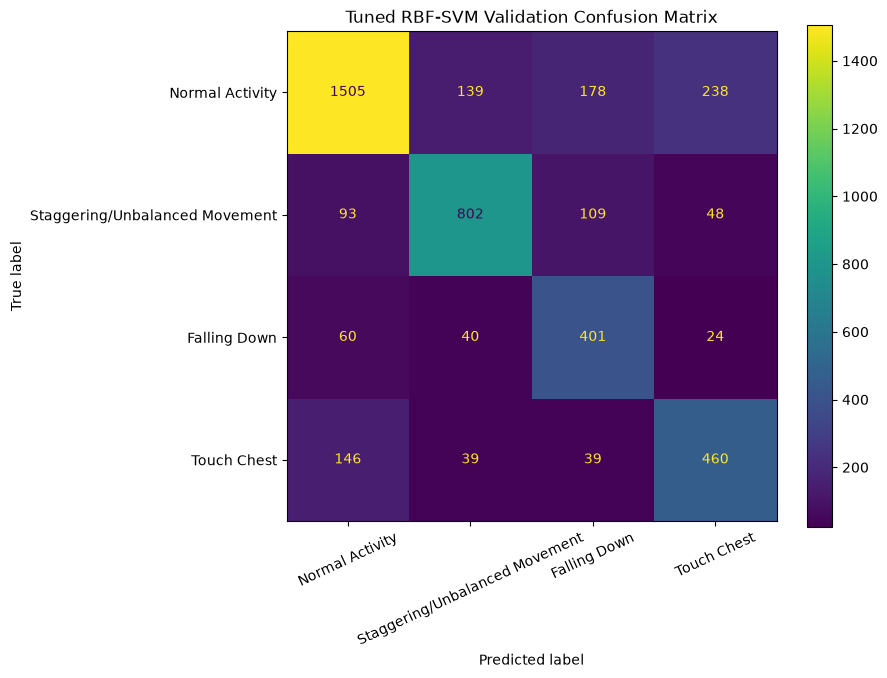

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_order = [
    "Normal Activity",
    "Staggering/Unbalanced Movement",
    "Falling Down",
    "Touch Chest"
]

svm_tuned_cm = confusion_matrix(
    y_val,
    svm_tuned_val_pred,
    labels=class_order
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=svm_tuned_cm,
    display_labels=class_order
)

fig, ax = plt.subplots(figsize=(9, 7))

disp.plot(
    ax=ax,
    values_format="d",
    xticks_rotation=25
)

plt.title("Tuned RBF-SVM Validation Confusion Matrix")
plt.tight_layout()
plt.show()

In [31]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Get validation probabilities
rf_val_proba = rf_tuned.predict_proba(X_val)
svm_val_proba = svm_tuned.predict_proba(X_val)

print("RF class order:")
print(rf_tuned.classes_)

print("\nSVM class order:")
print(svm_tuned.classes_)

print("\nSame class order:")
print(np.array_equal(rf_tuned.classes_, svm_tuned.classes_))

RF class order:
['Falling Down' 'Normal Activity' 'Staggering/Unbalanced Movement'
 'Touch Chest']

SVM class order:
['Falling Down' 'Normal Activity' 'Staggering/Unbalanced Movement'
 'Touch Chest']

Same class order:
True


In [32]:
ensemble_results = []

rf_weights = [
    0.2,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8
]

for rf_weight in rf_weights:

    svm_weight = 1.0 - rf_weight

    ensemble_proba = (
        rf_weight * rf_val_proba
        +
        svm_weight * svm_val_proba
    )

    ensemble_pred_indices = np.argmax(
        ensemble_proba,
        axis=1
    )

    ensemble_pred = rf_tuned.classes_[
        ensemble_pred_indices
    ]

    accuracy = accuracy_score(
        y_val,
        ensemble_pred
    )

    balanced_acc = balanced_accuracy_score(
        y_val,
        ensemble_pred
    )

    macro_precision = precision_score(
        y_val,
        ensemble_pred,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_val,
        ensemble_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_val,
        ensemble_pred,
        average="macro",
        zero_division=0
    )

    falling_recall = recall_score(
        y_val == "Falling Down",
        ensemble_pred == "Falling Down",
        zero_division=0
    )

    touch_recall = recall_score(
        y_val == "Touch Chest",
        ensemble_pred == "Touch Chest",
        zero_division=0
    )

    ensemble_results.append({
        "RF Weight": rf_weight,
        "SVM Weight": svm_weight,
        "Accuracy": accuracy,
        "Balanced Accuracy": balanced_acc,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Falling Recall": falling_recall,
        "Touch Chest Recall": touch_recall
    })

ensemble_results_df = pd.DataFrame(
    ensemble_results
)

ensemble_results_df = ensemble_results_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

display(ensemble_results_df)

,RF Weight,SVM Weight,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Falling Recall,Touch Chest Recall
0,0.6,0.4,0.743578,0.723055,0.703155,0.723055,0.710890,0.725714,0.605263
1,0.8,0.2,0.740338,0.715326,0.699450,0.715326,0.705485,0.708571,0.584795
2,0.5,0.5,0.737561,0.719981,0.696060,0.719981,0.705175,0.729524,0.614035
3,0.7,0.3,0.739412,0.714538,0.698119,0.714538,0.704305,0.704762,0.592105
4,0.4,0.6,0.734784,0.721910,0.693677,0.721910,0.704077,0.744762,0.624269
5,0.2,0.8,0.730849,0.727219,0.690054,0.727219,0.703414,0.760000,0.653509
6,0.3,0.7,0.732238,0.722400,0.691124,0.722400,0.702597,0.748571,0.633041


In [33]:
rf_weight = 0.60
svm_weight = 0.40

base_ensemble_proba = (
    rf_weight * rf_val_proba
    +
    svm_weight * svm_val_proba
)

classes = rf_tuned.classes_

fall_idx = np.where(classes == "Falling Down")[0][0]
touch_idx = np.where(classes == "Touch Chest")[0][0]

fall_multipliers = [1.00, 1.05, 1.10, 1.15, 1.20]
touch_multipliers = [1.00, 1.05, 1.10, 1.15, 1.20]

safety_results = []

for fall_mult in fall_multipliers:
    for touch_mult in touch_multipliers:

        adjusted_proba = base_ensemble_proba.copy()

        adjusted_proba[:, fall_idx] *= fall_mult
        adjusted_proba[:, touch_idx] *= touch_mult

        pred_indices = np.argmax(
            adjusted_proba,
            axis=1
        )

        adjusted_pred = classes[pred_indices]

        accuracy = accuracy_score(
            y_val,
            adjusted_pred
        )

        balanced_acc = balanced_accuracy_score(
            y_val,
            adjusted_pred
        )

        macro_precision = precision_score(
            y_val,
            adjusted_pred,
            average="macro",
            zero_division=0
        )

        macro_recall = recall_score(
            y_val,
            adjusted_pred,
            average="macro",
            zero_division=0
        )

        macro_f1 = f1_score(
            y_val,
            adjusted_pred,
            average="macro",
            zero_division=0
        )

        falling_recall = recall_score(
            y_val == "Falling Down",
            adjusted_pred == "Falling Down",
            zero_division=0
        )

        touch_recall = recall_score(
            y_val == "Touch Chest",
            adjusted_pred == "Touch Chest",
            zero_division=0
        )

        safety_avg_recall = (
            falling_recall + touch_recall
        ) / 2

        safety_results.append({
            "Falling Multiplier": fall_mult,
            "Touch Chest Multiplier": touch_mult,
            "Accuracy": accuracy,
            "Balanced Accuracy": balanced_acc,
            "Macro Precision": macro_precision,
            "Macro Recall": macro_recall,
            "Macro F1": macro_f1,
            "Falling Recall": falling_recall,
            "Touch Chest Recall": touch_recall,
            "Safety Avg Recall": safety_avg_recall
        })

safety_results_df = pd.DataFrame(
    safety_results
)

safety_results_df = safety_results_df.sort_values(
    by=["Macro F1", "Safety Avg Recall"],
    ascending=False
).reset_index(drop=True)

display(safety_results_df.head(15))

,Falling Multiplier,Touch Chest Multiplier,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Falling Recall,Touch Chest Recall,Safety Avg Recall
0,1.00,1.00,0.743578,0.723055,0.703155,0.723055,0.710890,0.725714,0.605263,0.665489
1,1.05,1.00,0.742189,0.722926,0.701717,0.722926,0.709724,0.731429,0.605263,0.668346
2,1.00,1.20,0.739412,0.725916,0.698307,0.725916,0.709620,0.725714,0.640351,0.683033
3,1.00,1.05,0.741032,0.723324,0.700107,0.723324,0.709497,0.725714,0.616959,0.671337
4,1.00,1.10,0.740106,0.724071,0.699007,0.724071,0.709245,0.725714,0.625731,0.675723
5,1.00,1.15,0.739412,0.724567,0.698185,0.724567,0.708994,0.725714,0.631579,0.678647
6,1.05,1.20,0.738024,0.725787,0.696883,0.725787,0.708443,0.731429,0.640351,0.685890
7,1.05,1.05,0.739644,0.723196,0.698673,0.723196,0.708326,0.731429,0.616959,0.674194
8,1.05,1.10,0.738718,0.723942,0.697578,0.723942,0.708071,0.731429,0.625731,0.678580
9,1.05,1.15,0.738024,0.724439,0.696757,0.724439,0.707818,0.731429,0.631579,0.681504


In [34]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    classification_report
)

final_rf_weight = 0.60
final_svm_weight = 0.40

ensemble_val_proba = (
    final_rf_weight * rf_val_proba
    +
    final_svm_weight * svm_val_proba
)

ensemble_val_pred = rf_tuned.classes_[
    np.argmax(ensemble_val_proba, axis=1)
]

ensemble_accuracy = accuracy_score(
    y_val,
    ensemble_val_pred
)

ensemble_balanced_acc = balanced_accuracy_score(
    y_val,
    ensemble_val_pred
)

ensemble_macro_precision = precision_score(
    y_val,
    ensemble_val_pred,
    average="macro",
    zero_division=0
)

ensemble_macro_recall = recall_score(
    y_val,
    ensemble_val_pred,
    average="macro",
    zero_division=0
)

ensemble_macro_f1 = f1_score(
    y_val,
    ensemble_val_pred,
    average="macro",
    zero_division=0
)

ensemble_weighted_f1 = f1_score(
    y_val,
    ensemble_val_pred,
    average="weighted",
    zero_division=0
)

ensemble_mcc = matthews_corrcoef(
    y_val,
    ensemble_val_pred
)

ensemble_kappa = cohen_kappa_score(
    y_val,
    ensemble_val_pred
)

print("RF-SVM ENSEMBLE VALIDATION RESULTS\n")

print(f"RF weight:          {final_rf_weight:.2f}")
print(f"SVM weight:         {final_svm_weight:.2f}")
print()
print(f"Accuracy:           {ensemble_accuracy:.4f}")
print(f"Balanced Accuracy:  {ensemble_balanced_acc:.4f}")
print(f"Macro Precision:    {ensemble_macro_precision:.4f}")
print(f"Macro Recall:       {ensemble_macro_recall:.4f}")
print(f"Macro F1:           {ensemble_macro_f1:.4f}")
print(f"Weighted F1:        {ensemble_weighted_f1:.4f}")
print(f"MCC:                {ensemble_mcc:.4f}")
print(f"Cohen's Kappa:      {ensemble_kappa:.4f}")

print("\nCLASSIFICATION REPORT")

print(
    classification_report(
        y_val,
        ensemble_val_pred,
        digits=4,
        zero_division=0
    )
)

RF-SVM ENSEMBLE VALIDATION RESULTS

RF weight:          0.60
SVM weight:         0.40

Accuracy:           0.7436
Balanced Accuracy:  0.7231
Macro Precision:    0.7032
Macro Recall:       0.7231
Macro F1:           0.7109
Weighted F1:        0.7452
MCC:                0.6250
Cohen's Kappa:      0.6243

CLASSIFICATION REPORT
                                precision    recall  f1-score   support

                  Falling Down     0.5808    0.7257    0.6452       525
               Normal Activity     0.8112    0.7694    0.7897      2060
Staggering/Unbalanced Movement     0.7896    0.7918    0.7907      1052
                   Touch Chest     0.6311    0.6053    0.6179       684

                      accuracy                         0.7436      4321
                     macro avg     0.7032    0.7231    0.7109      4321
                  weighted avg     0.7494    0.7436    0.7452      4321



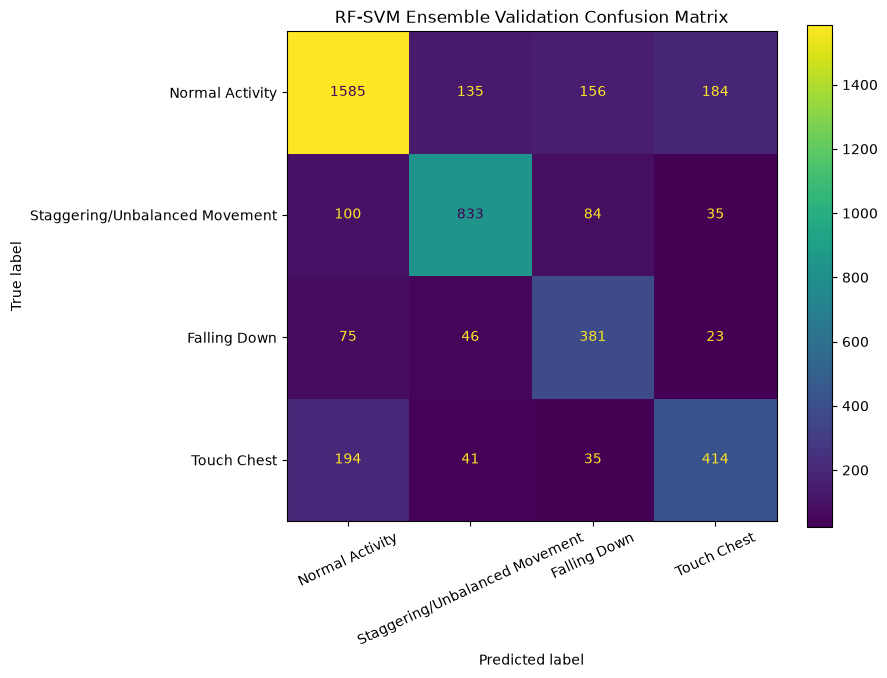

In [35]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_order = [
    "Normal Activity",
    "Staggering/Unbalanced Movement",
    "Falling Down",
    "Touch Chest"
]

ensemble_cm = confusion_matrix(
    y_val,
    ensemble_val_pred,
    labels=class_order
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=ensemble_cm,
    display_labels=class_order
)

fig, ax = plt.subplots(figsize=(9, 7))

disp.plot(
    ax=ax,
    values_format="d",
    xticks_rotation=25
)

plt.title("RF-SVM Ensemble Validation Confusion Matrix")
plt.tight_layout()
plt.show()

In [36]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

classes = rf_tuned.classes_

y_val_bin = label_binarize(
    y_val,
    classes=classes
)

rf_roc_auc_macro = roc_auc_score(
    y_val_bin,
    rf_val_proba,
    average="macro",
    multi_class="ovr"
)

rf_pr_auc_macro = average_precision_score(
    y_val_bin,
    rf_val_proba,
    average="macro"
)

svm_roc_auc_macro = roc_auc_score(
    y_val_bin,
    svm_val_proba,
    average="macro",
    multi_class="ovr"
)

svm_pr_auc_macro = average_precision_score(
    y_val_bin,
    svm_val_proba,
    average="macro"
)

ensemble_roc_auc_macro = roc_auc_score(
    y_val_bin,
    ensemble_val_proba,
    average="macro",
    multi_class="ovr"
)

ensemble_pr_auc_macro = average_precision_score(
    y_val_bin,
    ensemble_val_proba,
    average="macro"
)

print("VALIDATION ROC-AUC AND PR-AUC\n")

print("Tuned Random Forest")
print(f"Macro ROC-AUC: {rf_roc_auc_macro:.4f}")
print(f"Macro PR-AUC:  {rf_pr_auc_macro:.4f}")

print("\nTuned RBF-SVM")
print(f"Macro ROC-AUC: {svm_roc_auc_macro:.4f}")
print(f"Macro PR-AUC:  {svm_pr_auc_macro:.4f}")

print("\n60/40 RF-SVM Ensemble")
print(f"Macro ROC-AUC: {ensemble_roc_auc_macro:.4f}")
print(f"Macro PR-AUC:  {ensemble_pr_auc_macro:.4f}")

VALIDATION ROC-AUC AND PR-AUC

Tuned Random Forest
Macro ROC-AUC: 0.9106
Macro PR-AUC:  0.7784

Tuned RBF-SVM
Macro ROC-AUC: 0.8822
Macro PR-AUC:  0.6581

60/40 RF-SVM Ensemble
Macro ROC-AUC: 0.9118
Macro PR-AUC:  0.7829


In [37]:
from sklearn.metrics import roc_auc_score, average_precision_score

per_class_results = []

for i, class_name in enumerate(classes):

    rf_roc = roc_auc_score(
        y_val_bin[:, i],
        rf_val_proba[:, i]
    )

    rf_pr = average_precision_score(
        y_val_bin[:, i],
        rf_val_proba[:, i]
    )

    svm_roc = roc_auc_score(
        y_val_bin[:, i],
        svm_val_proba[:, i]
    )

    svm_pr = average_precision_score(
        y_val_bin[:, i],
        svm_val_proba[:, i]
    )

    ensemble_roc = roc_auc_score(
        y_val_bin[:, i],
        ensemble_val_proba[:, i]
    )

    ensemble_pr = average_precision_score(
        y_val_bin[:, i],
        ensemble_val_proba[:, i]
    )

    per_class_results.append({
        "Class": class_name,
        "RF ROC-AUC": rf_roc,
        "RF PR-AUC": rf_pr,
        "SVM ROC-AUC": svm_roc,
        "SVM PR-AUC": svm_pr,
        "Ensemble ROC-AUC": ensemble_roc,
        "Ensemble PR-AUC": ensemble_pr
    })

per_class_auc_df = pd.DataFrame(per_class_results)

display(per_class_auc_df.round(4))

,Class,RF ROC-AUC,RF PR-AUC,SVM ROC-AUC,SVM PR-AUC,Ensemble ROC-AUC,Ensemble PR-AUC
0,Falling Down,0.9246,0.7007,0.9044,0.5078,0.9310,0.7103
1,Normal Activity,0.8833,0.8751,0.8407,0.7974,0.8820,0.8793
2,Staggering/Unbalanced Movement,0.9428,0.8578,0.9161,0.7813,0.9423,0.8563
3,Touch Chest,0.8916,0.6802,0.8674,0.5458,0.8919,0.6856


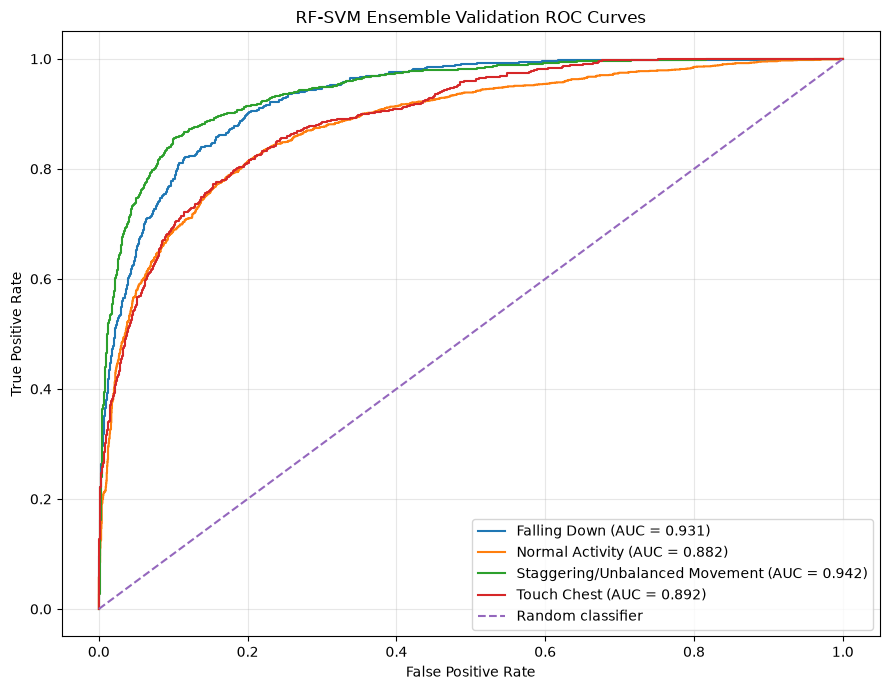

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(9, 7))

for i, class_name in enumerate(classes):

    fpr, tpr, _ = roc_curve(
        y_val_bin[:, i],
        ensemble_val_proba[:, i]
    )

    class_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {class_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("RF-SVM Ensemble Validation ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

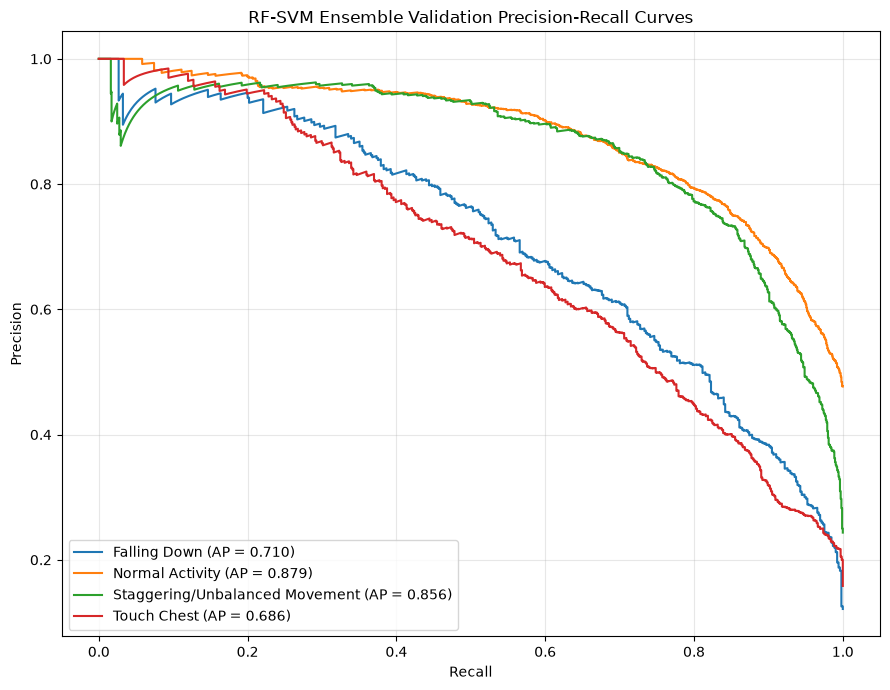

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(9, 7))

for i, class_name in enumerate(classes):

    precision, recall, _ = precision_recall_curve(
        y_val_bin[:, i],
        ensemble_val_proba[:, i]
    )

    ap = average_precision_score(
        y_val_bin[:, i],
        ensemble_val_proba[:, i]
    )

    plt.plot(
        recall,
        precision,
        label=f"{class_name} (AP = {ap:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("RF-SVM Ensemble Validation Precision-Recall Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

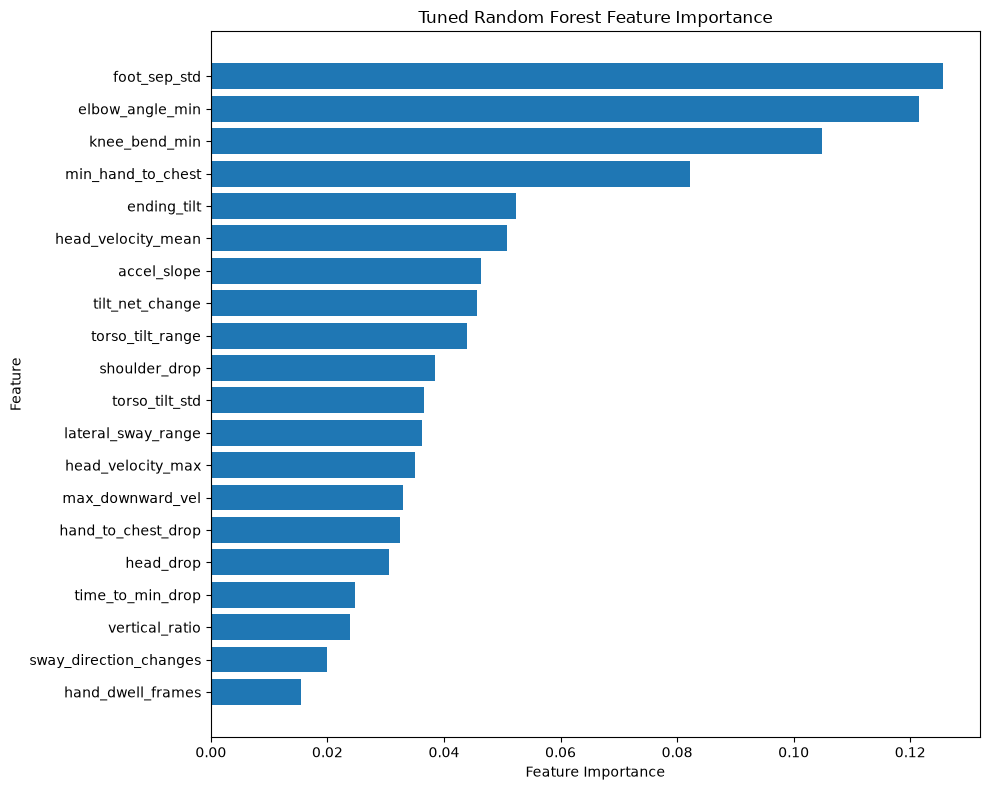

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_tuned.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Tuned Random Forest Feature Importance")
plt.tight_layout()
plt.show()

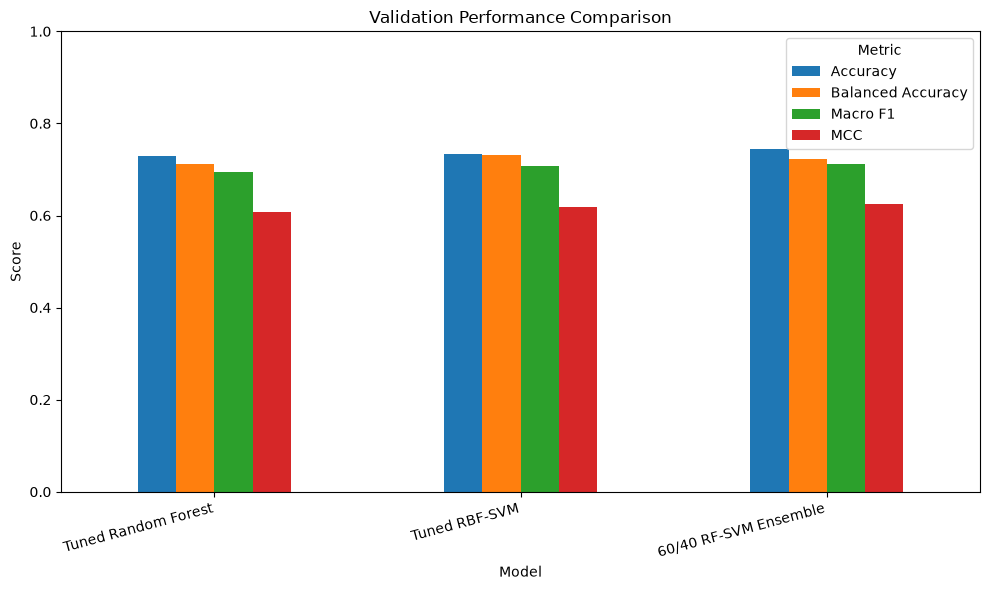

,Model,Accuracy,Balanced Accuracy,Macro F1,MCC
0,Tuned Random Forest,0.7297,0.7117,0.6953,0.6080
1,Tuned RBF-SVM,0.7332,0.7323,0.7066,0.6189
2,60/40 RF-SVM Ensemble,0.7436,0.7231,0.7109,0.6250


In [41]:
import pandas as pd
import matplotlib.pyplot as plt

model_comparison = pd.DataFrame({
    "Model": [
        "Tuned Random Forest",
        "Tuned RBF-SVM",
        "60/40 RF-SVM Ensemble"
    ],
    "Accuracy": [
        0.7297,
        0.7332,
        0.7436
    ],
    "Balanced Accuracy": [
        0.7117,
        0.7323,
        0.7231
    ],
    "Macro F1": [
        0.6953,
        0.7066,
        0.7109
    ],
    "MCC": [
        0.6080,
        0.6189,
        0.6250
    ]
})

plot_df = model_comparison.set_index("Model")

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Validation Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

display(model_comparison.round(4))

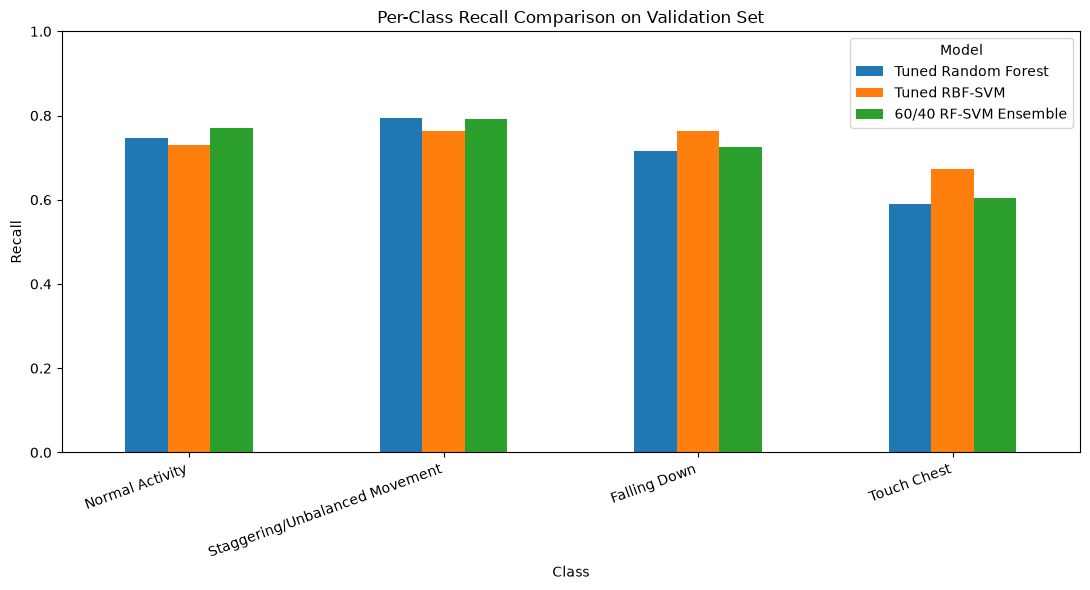

,Class,Tuned Random Forest,Tuned RBF-SVM,60/40 RF-SVM Ensemble
0,Normal Activity,0.7466,0.7306,0.7694
1,Staggering/Unbalanced Movement,0.7947,0.7624,0.7918
2,Falling Down,0.7162,0.7638,0.7257
3,Touch Chest,0.5892,0.6725,0.6053


In [42]:
from sklearn.metrics import recall_score
import pandas as pd
import matplotlib.pyplot as plt

class_order = [
    "Normal Activity",
    "Staggering/Unbalanced Movement",
    "Falling Down",
    "Touch Chest"
]

rf_recalls = recall_score(
    y_val,
    rf_tuned_val_pred,
    labels=class_order,
    average=None
)

svm_recalls = recall_score(
    y_val,
    svm_tuned_val_pred,
    labels=class_order,
    average=None
)

ensemble_recalls = recall_score(
    y_val,
    ensemble_val_pred,
    labels=class_order,
    average=None
)

recall_comparison_df = pd.DataFrame({
    "Class": class_order,
    "Tuned Random Forest": rf_recalls,
    "Tuned RBF-SVM": svm_recalls,
    "60/40 RF-SVM Ensemble": ensemble_recalls
})

plot_df = recall_comparison_df.set_index("Class")

ax = plot_df.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Per-Class Recall Comparison on Validation Set")
plt.xlabel("Class")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

display(recall_comparison_df.round(4))

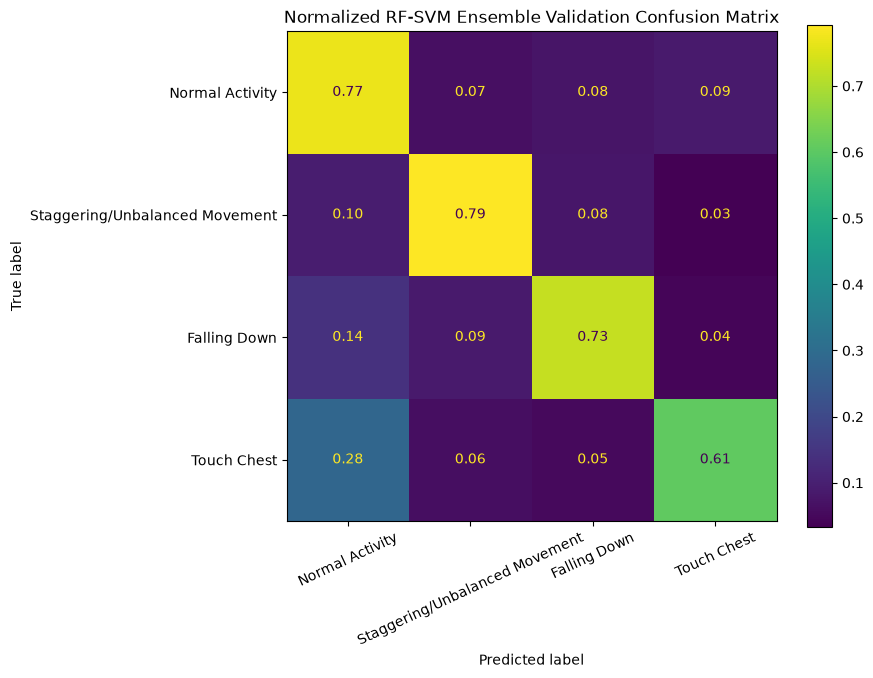

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_order = [
    "Normal Activity",
    "Staggering/Unbalanced Movement",
    "Falling Down",
    "Touch Chest"
]

ensemble_cm_normalized = confusion_matrix(
    y_val,
    ensemble_val_pred,
    labels=class_order,
    normalize="true"
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=ensemble_cm_normalized,
    display_labels=class_order
)

fig, ax = plt.subplots(figsize=(9, 7))

disp.plot(
    ax=ax,
    values_format=".2f",
    xticks_rotation=25
)

plt.title("Normalized RF-SVM Ensemble Validation Confusion Matrix")
plt.tight_layout()
plt.show()

In [44]:
final_config = {
    "Random Forest": {
        "n_estimators": 300,
        "max_depth": 15,
        "min_samples_split": 2,
        "min_samples_leaf": 2,
        "max_features": 3,
        "bootstrap": True,
        "class_weight": "balanced",
        "random_state": 42
    },

    "RBF-SVM": {
        "kernel": "rbf",
        "C": 2.0,
        "gamma": "scale",
        "class_weight": "balanced",
        "scaling": "StandardScaler",
        "calibration": "sigmoid",
        "calibration_cv": 5
    },

    "Ensemble": {
        "RF_weight": 0.60,
        "SVM_weight": 0.40,
        "Falling_multiplier": 1.00,
        "Touch_Chest_multiplier": 1.00
    }
}

print("FINAL VALIDATION-SELECTED CONFIGURATION\n")

for section, settings in final_config.items():
    print(section)

    for key, value in settings.items():
        print(f"  {key}: {value}")

    print()

print("Validation metrics:")
print(f"Accuracy:          {ensemble_accuracy:.4f}")
print(f"Balanced Accuracy: {ensemble_balanced_acc:.4f}")
print(f"Macro F1:          {ensemble_macro_f1:.4f}")
print(f"Weighted F1:       {ensemble_weighted_f1:.4f}")
print(f"MCC:               {ensemble_mcc:.4f}")
print(f"Cohen's Kappa:     {ensemble_kappa:.4f}")
print(f"Macro ROC-AUC:     {ensemble_roc_auc_macro:.4f}")
print(f"Macro PR-AUC:      {ensemble_pr_auc_macro:.4f}")

print("\nMODEL DEVELOPMENT LOCKED.")
print("No further tuning should use the test set.")

FINAL VALIDATION-SELECTED CONFIGURATION

Random Forest
  n_estimators: 300
  max_depth: 15
  min_samples_split: 2
  min_samples_leaf: 2
  max_features: 3
  bootstrap: True
  class_weight: balanced
  random_state: 42

RBF-SVM
  kernel: rbf
  C: 2.0
  gamma: scale
  class_weight: balanced
  scaling: StandardScaler
  calibration: sigmoid
  calibration_cv: 5

Ensemble
  RF_weight: 0.6
  SVM_weight: 0.4
  Falling_multiplier: 1.0
  Touch_Chest_multiplier: 1.0

Validation metrics:
Accuracy:          0.7436
Balanced Accuracy: 0.7231
Macro F1:          0.7109
Weighted F1:       0.7452
MCC:               0.6250
Cohen's Kappa:     0.6243
Macro ROC-AUC:     0.9118
Macro PR-AUC:      0.7829

MODEL DEVELOPMENT LOCKED.
No further tuning should use the test set.


In [45]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    classification_report
)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np

# Get test-set probabilities
rf_test_proba = rf_tuned.predict_proba(X_test)
svm_test_proba = svm_tuned.predict_proba(X_test)

# Combine probabilities using locked 60/40 weights
ensemble_test_proba = (
    0.60 * rf_test_proba
    +
    0.40 * svm_test_proba
)

# Final test predictions
ensemble_test_pred = rf_tuned.classes_[
    np.argmax(ensemble_test_proba, axis=1)
]

# Overall metrics
test_accuracy = accuracy_score(
    y_test,
    ensemble_test_pred
)

test_balanced_acc = balanced_accuracy_score(
    y_test,
    ensemble_test_pred
)

test_macro_precision = precision_score(
    y_test,
    ensemble_test_pred,
    average="macro",
    zero_division=0
)

test_macro_recall = recall_score(
    y_test,
    ensemble_test_pred,
    average="macro",
    zero_division=0
)

test_macro_f1 = f1_score(
    y_test,
    ensemble_test_pred,
    average="macro",
    zero_division=0
)

test_weighted_f1 = f1_score(
    y_test,
    ensemble_test_pred,
    average="weighted",
    zero_division=0
)

test_mcc = matthews_corrcoef(
    y_test,
    ensemble_test_pred
)

test_kappa = cohen_kappa_score(
    y_test,
    ensemble_test_pred
)

# ROC-AUC and PR-AUC
classes = rf_tuned.classes_

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

test_roc_auc = roc_auc_score(
    y_test_bin,
    ensemble_test_proba,
    average="macro",
    multi_class="ovr"
)

test_pr_auc = average_precision_score(
    y_test_bin,
    ensemble_test_proba,
    average="macro"
)

print("FINAL UNTOUCHED TEST-SET RESULTS\n")

print(f"Accuracy:           {test_accuracy:.4f}")
print(f"Balanced Accuracy:  {test_balanced_acc:.4f}")
print(f"Macro Precision:    {test_macro_precision:.4f}")
print(f"Macro Recall:       {test_macro_recall:.4f}")
print(f"Macro F1:           {test_macro_f1:.4f}")
print(f"Weighted F1:        {test_weighted_f1:.4f}")
print(f"MCC:                {test_mcc:.4f}")
print(f"Cohen's Kappa:      {test_kappa:.4f}")
print(f"Macro ROC-AUC:      {test_roc_auc:.4f}")
print(f"Macro PR-AUC:       {test_pr_auc:.4f}")

print("\nFINAL TEST CLASSIFICATION REPORT")

print(
    classification_report(
        y_test,
        ensemble_test_pred,
        digits=4,
        zero_division=0
    )
)

FINAL UNTOUCHED TEST-SET RESULTS

Accuracy:           0.7645
Balanced Accuracy:  0.7461
Macro Precision:    0.7342
Macro Recall:       0.7461
Macro F1:           0.7390
Weighted F1:        0.7649
MCC:                0.6550
Cohen's Kappa:      0.6543
Macro ROC-AUC:      0.9242
Macro PR-AUC:       0.8209

FINAL TEST CLASSIFICATION REPORT
                                precision    recall  f1-score   support

                  Falling Down     0.6667    0.6292    0.6474       267
               Normal Activity     0.8212    0.7757    0.7978      1030
Staggering/Unbalanced Movement     0.7730    0.8078    0.7900       510
                   Touch Chest     0.6759    0.7717    0.7206       346

                      accuracy                         0.7645      2153
                     macro avg     0.7342    0.7461    0.7390      2153
                  weighted avg     0.7673    0.7645    0.7649      2153



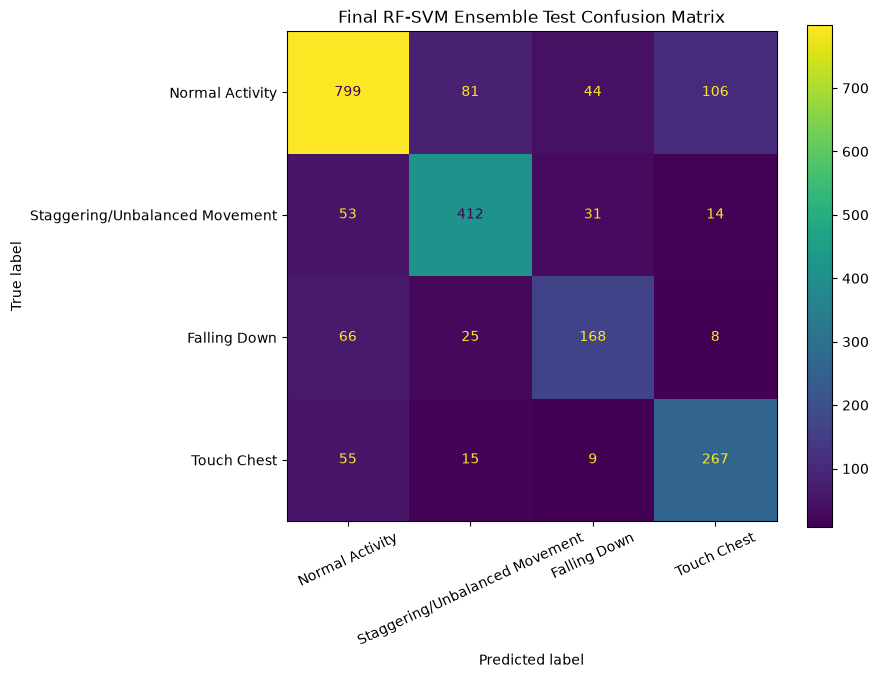

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_order = [
    "Normal Activity",
    "Staggering/Unbalanced Movement",
    "Falling Down",
    "Touch Chest"
]

test_cm = confusion_matrix(
    y_test,
    ensemble_test_pred,
    labels=class_order
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=test_cm,
    display_labels=class_order
)

fig, ax = plt.subplots(figsize=(9, 7))

disp.plot(
    ax=ax,
    values_format="d",
    xticks_rotation=25
)

plt.title("Final RF-SVM Ensemble Test Confusion Matrix")
plt.tight_layout()
plt.show()

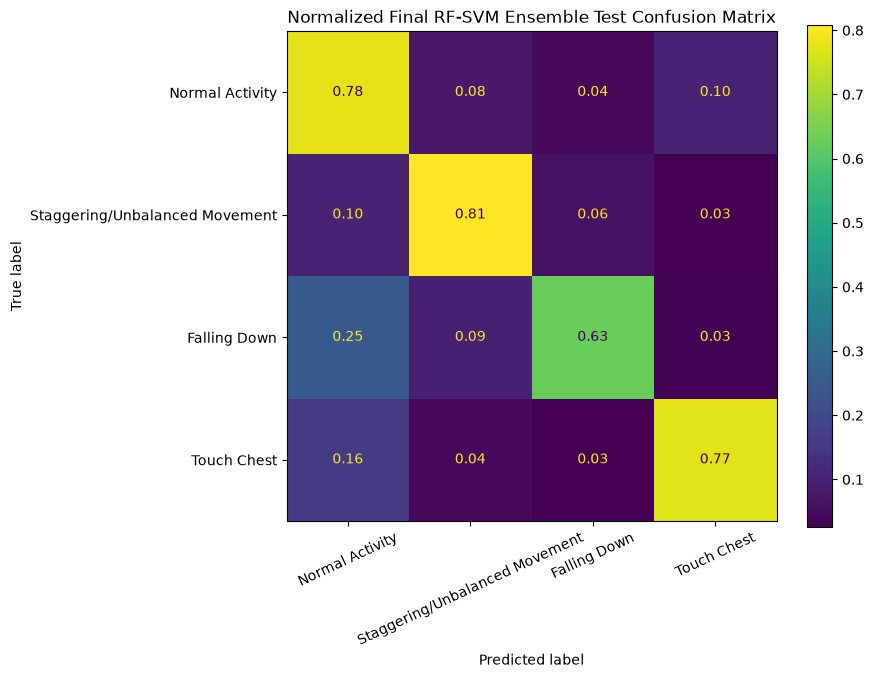

In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_order = [
    "Normal Activity",
    "Staggering/Unbalanced Movement",
    "Falling Down",
    "Touch Chest"
]

test_cm_normalized = confusion_matrix(
    y_test,
    ensemble_test_pred,
    labels=class_order,
    normalize="true"
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=test_cm_normalized,
    display_labels=class_order
)

fig, ax = plt.subplots(figsize=(9, 7))

disp.plot(
    ax=ax,
    values_format=".2f",
    xticks_rotation=25
)

plt.title("Normalized Final RF-SVM Ensemble Test Confusion Matrix")
plt.tight_layout()
plt.show()

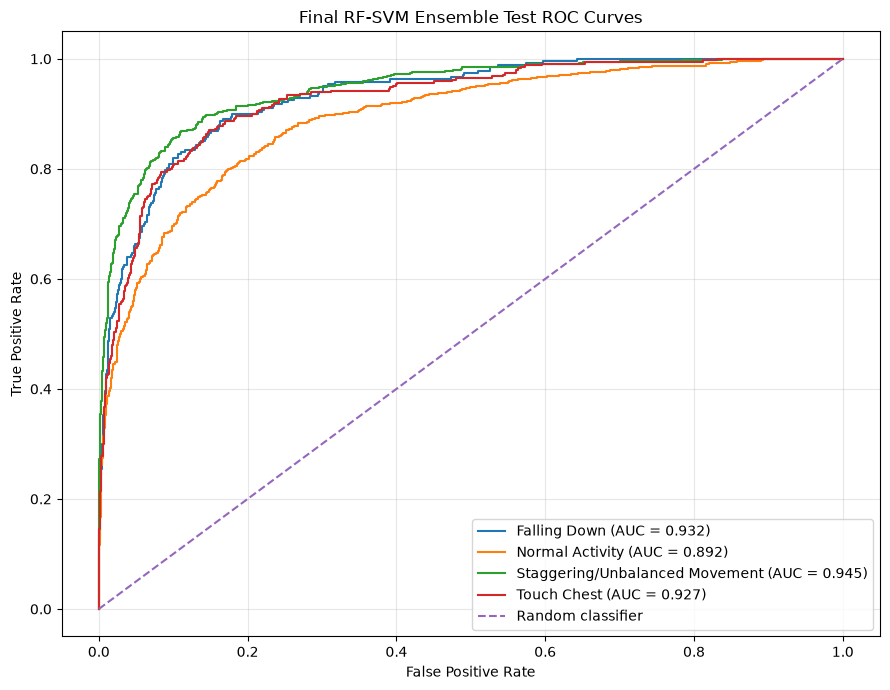

In [48]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

plt.figure(figsize=(9, 7))

for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        ensemble_test_proba[:, i]
    )

    class_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {class_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final RF-SVM Ensemble Test ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

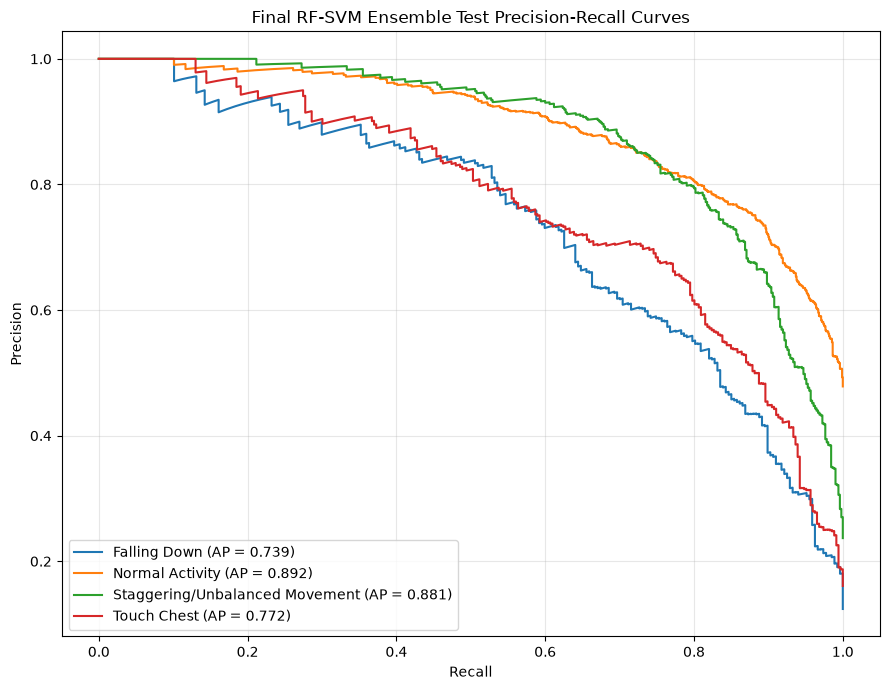

In [49]:
plt.figure(figsize=(9, 7))

for i, class_name in enumerate(classes):
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        ensemble_test_proba[:, i]
    )

    ap = average_precision_score(
        y_test_bin[:, i],
        ensemble_test_proba[:, i]
    )

    plt.plot(
        recall,
        precision,
        label=f"{class_name} (AP = {ap:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Final RF-SVM Ensemble Test Precision-Recall Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [50]:
from sklearn.metrics import roc_auc_score, average_precision_score
import pandas as pd

final_auc_results = []

for i, class_name in enumerate(classes):

    class_roc_auc = roc_auc_score(
        y_test_bin[:, i],
        ensemble_test_proba[:, i]
    )

    class_pr_auc = average_precision_score(
        y_test_bin[:, i],
        ensemble_test_proba[:, i]
    )

    final_auc_results.append({
        "Class": class_name,
        "ROC-AUC": class_roc_auc,
        "PR-AUC": class_pr_auc
    })

final_auc_df = pd.DataFrame(final_auc_results)

display(final_auc_df.round(4))

,Class,ROC-AUC,PR-AUC
0,Falling Down,0.9324,0.7386
1,Normal Activity,0.8921,0.8923
2,Staggering/Unbalanced Movement,0.9452,0.8810
3,Touch Chest,0.9273,0.7718


In [51]:
import joblib
import json
import os

os.makedirs("models", exist_ok=True)

rf_model_path = "models/final_random_forest.joblib"
svm_model_path = "models/final_rbf_svm.joblib"
metadata_path = "models/final_rf_svm_metadata.json"

joblib.dump(
    rf_tuned,
    rf_model_path
)

joblib.dump(
    svm_tuned,
    svm_model_path
)

final_metadata = {
    "feature_columns": feature_cols,

    "class_order": rf_tuned.classes_.tolist(),

    "random_forest": {
        "n_estimators": 300,
        "max_depth": 15,
        "min_samples_split": 2,
        "min_samples_leaf": 2,
        "max_features": 3,
        "bootstrap": True,
        "class_weight": "balanced",
        "random_state": 42
    },

    "rbf_svm": {
        "kernel": "rbf",
        "C": 2.0,
        "gamma": "scale",
        "class_weight": "balanced",
        "scaling": "StandardScaler",
        "calibration": "sigmoid",
        "calibration_cv": 5
    },

    "ensemble": {
        "rf_weight": 0.60,
        "svm_weight": 0.40,
        "falling_multiplier": 1.00,
        "touch_chest_multiplier": 1.00
    },

    "final_test_metrics": {
        "accuracy": float(test_accuracy),
        "balanced_accuracy": float(test_balanced_acc),
        "macro_precision": float(test_macro_precision),
        "macro_recall": float(test_macro_recall),
        "macro_f1": float(test_macro_f1),
        "weighted_f1": float(test_weighted_f1),
        "mcc": float(test_mcc),
        "cohens_kappa": float(test_kappa),
        "macro_roc_auc": float(test_roc_auc),
        "macro_pr_auc": float(test_pr_auc)
    }
}

with open(metadata_path, "w") as f:
    json.dump(
        final_metadata,
        f,
        indent=4
    )

print("Final models saved successfully.\n")

print("Random Forest:")
print(rf_model_path)

print("\nRBF-SVM:")
print(svm_model_path)

print("\nMetadata:")
print(metadata_path)

Final models saved successfully.

Random Forest:
models/final_random_forest.joblib

RBF-SVM:
models/final_rbf_svm.joblib

Metadata:
models/final_rf_svm_metadata.json


In [52]:
import joblib
import json
import numpy as np

# Reload saved models
rf_loaded = joblib.load(
    "models/final_random_forest.joblib"
)

svm_loaded = joblib.load(
    "models/final_rbf_svm.joblib"
)

# Reload metadata
with open(
    "models/final_rf_svm_metadata.json",
    "r"
) as f:
    metadata_loaded = json.load(f)

print("Saved files reloaded successfully.\n")

print("RF weight:", metadata_loaded["ensemble"]["rf_weight"])
print("SVM weight:", metadata_loaded["ensemble"]["svm_weight"])

print("\nNumber of saved features:")
print(len(metadata_loaded["feature_columns"]))

print("\nSaved class order:")
print(metadata_loaded["class_order"])

# Recalculate test probabilities
rf_loaded_proba = rf_loaded.predict_proba(X_test)
svm_loaded_proba = svm_loaded.predict_proba(X_test)

loaded_ensemble_proba = (
    metadata_loaded["ensemble"]["rf_weight"]
    * rf_loaded_proba
    +
    metadata_loaded["ensemble"]["svm_weight"]
    * svm_loaded_proba
)

loaded_test_pred = rf_loaded.classes_[
    np.argmax(
        loaded_ensemble_proba,
        axis=1
    )
]

# Compare old predictions with reloaded-model predictions
same_predictions = np.array_equal(
    ensemble_test_pred,
    loaded_test_pred
)

max_probability_difference = np.max(
    np.abs(
        ensemble_test_proba
        -
        loaded_ensemble_proba
    )
)

print("\nVerification results:")
print("Predictions identical:", same_predictions)
print(
    "Maximum probability difference:",
    max_probability_difference
)

Saved files reloaded successfully.

RF weight: 0.6
SVM weight: 0.4

Number of saved features:
20

Saved class order:
['Falling Down', 'Normal Activity', 'Staggering/Unbalanced Movement', 'Touch Chest']

Verification results:
Predictions identical: True
Maximum probability difference: 2.220446049250313e-16


In [53]:
import pandas as pd
import numpy as np

# Take one sample from the test set
sample_index = 0

single_sample = X_test.iloc[[sample_index]]

true_label = y_test.iloc[sample_index]

# Predict probabilities using loaded models
rf_single_proba = rf_loaded.predict_proba(single_sample)
svm_single_proba = svm_loaded.predict_proba(single_sample)

# Combine with final ensemble weights
ensemble_single_proba = (
    metadata_loaded["ensemble"]["rf_weight"] * rf_single_proba
    +
    metadata_loaded["ensemble"]["svm_weight"] * svm_single_proba
)

# Final predicted class
predicted_index = np.argmax(
    ensemble_single_proba,
    axis=1
)[0]

predicted_class = rf_loaded.classes_[predicted_index]

print("SINGLE-SAMPLE INFERENCE TEST\n")

print("True label:")
print(true_label)

print("\nPredicted label:")
print(predicted_class)

print("\nClass probabilities:")

for class_name, probability in zip(
    rf_loaded.classes_,
    ensemble_single_proba[0]
):
    print(
        f"{class_name}: {probability:.4f}"
    )

SINGLE-SAMPLE INFERENCE TEST

True label:
Normal Activity

Predicted label:
Normal Activity

Class probabilities:
Falling Down: 0.0142
Normal Activity: 0.7314
Staggering/Unbalanced Movement: 0.0126
Touch Chest: 0.2419


In [54]:
import pandas as pd

final_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1",
        "MCC",
        "Cohen's Kappa",
        "Macro ROC-AUC",
        "Macro PR-AUC"
    ],

    "Validation": [
        ensemble_accuracy,
        ensemble_balanced_acc,
        ensemble_macro_precision,
        ensemble_macro_recall,
        ensemble_macro_f1,
        ensemble_weighted_f1,
        ensemble_mcc,
        ensemble_kappa,
        ensemble_roc_auc_macro,
        ensemble_pr_auc_macro
    ],

    "Final Test": [
        test_accuracy,
        test_balanced_acc,
        test_macro_precision,
        test_macro_recall,
        test_macro_f1,
        test_weighted_f1,
        test_mcc,
        test_kappa,
        test_roc_auc,
        test_pr_auc
    ]
})

print("FINAL RF-SVM MODEL PERFORMANCE SUMMARY\n")

display(final_summary.round(4))

FINAL RF-SVM MODEL PERFORMANCE SUMMARY



,Metric,Validation,Final Test
0,Accuracy,0.7436,0.7645
1,Balanced Accuracy,0.7231,0.7461
2,Macro Precision,0.7032,0.7342
3,Macro Recall,0.7231,0.7461
4,Macro F1,0.7109,0.7390
5,Weighted F1,0.7452,0.7649
6,MCC,0.6250,0.6550
7,Cohen's Kappa,0.6243,0.6543
8,Macro ROC-AUC,0.9118,0.9242
9,Macro PR-AUC,0.7829,0.8209


In [55]:
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

class_order = [
    "Normal Activity",
    "Staggering/Unbalanced Movement",
    "Falling Down",
    "Touch Chest"
]

precision_values, recall_values, f1_values, support_values = (
    precision_recall_fscore_support(
        y_test,
        ensemble_test_pred,
        labels=class_order,
        zero_division=0
    )
)

final_class_summary = pd.DataFrame({
    "Class": class_order,
    "Precision": precision_values,
    "Recall": recall_values,
    "F1-Score": f1_values,
    "Support": support_values
})

print("FINAL PER-CLASS TEST PERFORMANCE\n")

display(final_class_summary.round(4))

FINAL PER-CLASS TEST PERFORMANCE



,Class,Precision,Recall,F1-Score,Support
0,Normal Activity,0.8212,0.7757,0.7978,1030
1,Staggering/Unbalanced Movement,0.7730,0.8078,0.7900,510
2,Falling Down,0.6667,0.6292,0.6474,267
3,Touch Chest,0.6759,0.7717,0.7206,346


In [56]:
print("FINAL MODEL TRAINING SUMMARY")
print()

print("Dataset:")
print("Train samples: 15140")
print("Validation samples: 4321")
print("Test samples: 2153")
print("Number of features: 20")
print("Subject overlap: None")
print()

print("Random Forest:")
print("Trees: 300")
print("Bootstrap / Bagging: Enabled")
print("mtry / max_features: 3")
print("Max depth: 15")
print("Min samples leaf: 2")
print("Class weighting: Balanced")
print()

print("RBF-SVM:")
print("Kernel: RBF")
print("C: 2.0")
print("Gamma: scale")
print("Scaling: StandardScaler")
print("Class weighting: Balanced")
print("Probability calibration: Sigmoid, 5-fold")
print()

print("Final Ensemble:")
print("Random Forest weight: 60%")
print("RBF-SVM weight: 40%")
print("Safety multipliers: Not used in primary final model")
print()

print("Final Untouched Test Performance:")
print("Accuracy: 0.7645")
print("Balanced Accuracy: 0.7461")
print("Macro F1: 0.7390")
print("Weighted F1: 0.7649")
print("MCC: 0.6550")
print("Cohen's Kappa: 0.6543")
print("Macro ROC-AUC: 0.9242")
print("Macro PR-AUC: 0.8209")
print()

print("Final per-class recall:")
print("Normal Activity: 0.7757")
print("Staggering/Unbalanced Movement: 0.8078")
print("Falling Down: 0.6292")
print("Touch Chest: 0.7717")
print()

print("Final trained models were saved and successfully reloaded.")
print("Reloaded predictions were identical to the original predictions.")
print()
print("MODEL TRAINING PIPELINE COMPLETE.")

FINAL MODEL TRAINING SUMMARY

Dataset:
Train samples: 15140
Validation samples: 4321
Test samples: 2153
Number of features: 20
Subject overlap: None

Random Forest:
Trees: 300
Bootstrap / Bagging: Enabled
mtry / max_features: 3
Max depth: 15
Min samples leaf: 2
Class weighting: Balanced

RBF-SVM:
Kernel: RBF
C: 2.0
Gamma: scale
Scaling: StandardScaler
Class weighting: Balanced
Probability calibration: Sigmoid, 5-fold

Final Ensemble:
Random Forest weight: 60%
RBF-SVM weight: 40%
Safety multipliers: Not used in primary final model

Final Untouched Test Performance:
Accuracy: 0.7645
Balanced Accuracy: 0.7461
Macro F1: 0.7390
Weighted F1: 0.7649
MCC: 0.6550
Cohen's Kappa: 0.6543
Macro ROC-AUC: 0.9242
Macro PR-AUC: 0.8209

Final per-class recall:
Normal Activity: 0.7757
Staggering/Unbalanced Movement: 0.8078
Falling Down: 0.6292
Touch Chest: 0.7717

Final trained models were saved and successfully reloaded.
Reloaded predictions were identical to the original predictions.

MODEL TRAINING PI

In [57]:
from sklearn.ensemble import RandomForestClassifier
import time

rf_oob = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features=3,
    bootstrap=True,
    oob_score=True,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

rf_oob.fit(X_train, y_train)

training_time = time.time() - start_time

print("OOB-enabled Random Forest trained successfully.")
print(f"Training time: {training_time:.2f} seconds")

print("\nOOB settings:")
print("Bootstrap enabled:", rf_oob.bootstrap)
print("OOB scoring enabled:", rf_oob.oob_score)

print("\nOOB Accuracy:")
print(f"{rf_oob.oob_score_:.4f}")

OOB-enabled Random Forest trained successfully.
Training time: 1.96 seconds

OOB settings:
Bootstrap enabled: True
OOB scoring enabled: True

OOB Accuracy:
0.7939


RANDOM FOREST OOB RESULTS

Accuracy:           0.7939
Balanced Accuracy:  0.7976
Macro Precision:    0.7588
Macro Recall:       0.7976
Macro F1:           0.7747
MCC:                0.7054
Cohen's Kappa:      0.7027

OOB CLASSIFICATION REPORT
                                precision    recall  f1-score   support

                  Falling Down     0.6319    0.7822    0.6991      1846
               Normal Activity     0.8818    0.7704    0.8223      7185
Staggering/Unbalanced Movement     0.7874    0.8485    0.8168      3684
                   Touch Chest     0.7339    0.7893    0.7606      2425

                      accuracy                         0.7939     15140
                     macro avg     0.7588    0.7976    0.7747     15140
                  weighted avg     0.8047    0.7939    0.7961     15140



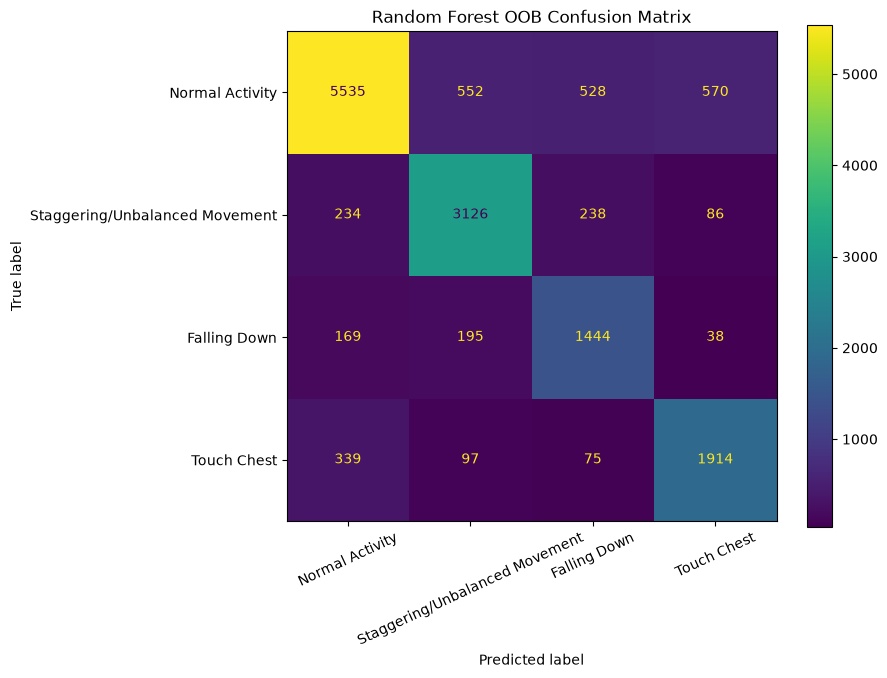

In [58]:
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# Convert OOB probability estimates into predicted classes
oob_pred_indices = np.argmax(
    rf_oob.oob_decision_function_,
    axis=1
)

oob_pred = rf_oob.classes_[
    oob_pred_indices
]

# Overall OOB metrics
oob_accuracy = accuracy_score(
    y_train,
    oob_pred
)

oob_balanced_acc = balanced_accuracy_score(
    y_train,
    oob_pred
)

oob_macro_precision = precision_score(
    y_train,
    oob_pred,
    average="macro",
    zero_division=0
)

oob_macro_recall = recall_score(
    y_train,
    oob_pred,
    average="macro",
    zero_division=0
)

oob_macro_f1 = f1_score(
    y_train,
    oob_pred,
    average="macro",
    zero_division=0
)

oob_mcc = matthews_corrcoef(
    y_train,
    oob_pred
)

oob_kappa = cohen_kappa_score(
    y_train,
    oob_pred
)

print("RANDOM FOREST OOB RESULTS\n")

print(f"Accuracy:           {oob_accuracy:.4f}")
print(f"Balanced Accuracy:  {oob_balanced_acc:.4f}")
print(f"Macro Precision:    {oob_macro_precision:.4f}")
print(f"Macro Recall:       {oob_macro_recall:.4f}")
print(f"Macro F1:           {oob_macro_f1:.4f}")
print(f"MCC:                {oob_mcc:.4f}")
print(f"Cohen's Kappa:      {oob_kappa:.4f}")

print("\nOOB CLASSIFICATION REPORT")

print(
    classification_report(
        y_train,
        oob_pred,
        digits=4,
        zero_division=0
    )
)

class_order = [
    "Normal Activity",
    "Staggering/Unbalanced Movement",
    "Falling Down",
    "Touch Chest"
]

oob_cm = confusion_matrix(
    y_train,
    oob_pred,
    labels=class_order
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=oob_cm,
    display_labels=class_order
)

fig, ax = plt.subplots(figsize=(9, 7))

disp.plot(
    ax=ax,
    values_format="d",
    xticks_rotation=25
)

plt.title("Random Forest OOB Confusion Matrix")
plt.tight_layout()
plt.show()

In [59]:
import pandas as pd

oob_comparison = pd.DataFrame({
    "Evaluation": [
        "Random Forest OOB",
        "RF-SVM Validation",
        "RF-SVM Final Test"
    ],
    "Accuracy": [
        oob_accuracy,
        ensemble_accuracy,
        test_accuracy
    ],
    "Balanced Accuracy": [
        oob_balanced_acc,
        ensemble_balanced_acc,
        test_balanced_acc
    ],
    "Macro F1": [
        oob_macro_f1,
        ensemble_macro_f1,
        test_macro_f1
    ],
    "MCC": [
        oob_mcc,
        ensemble_mcc,
        test_mcc
    ]
})

print("OOB AND EXTERNAL EVALUATION SUMMARY\n")

display(oob_comparison.round(4))

OOB AND EXTERNAL EVALUATION SUMMARY



,Evaluation,Accuracy,Balanced Accuracy,Macro F1,MCC
0,Random Forest OOB,0.7939,0.7976,0.7747,0.7054
1,RF-SVM Validation,0.7436,0.7231,0.7109,0.6250
2,RF-SVM Final Test,0.7645,0.7461,0.7390,0.6550


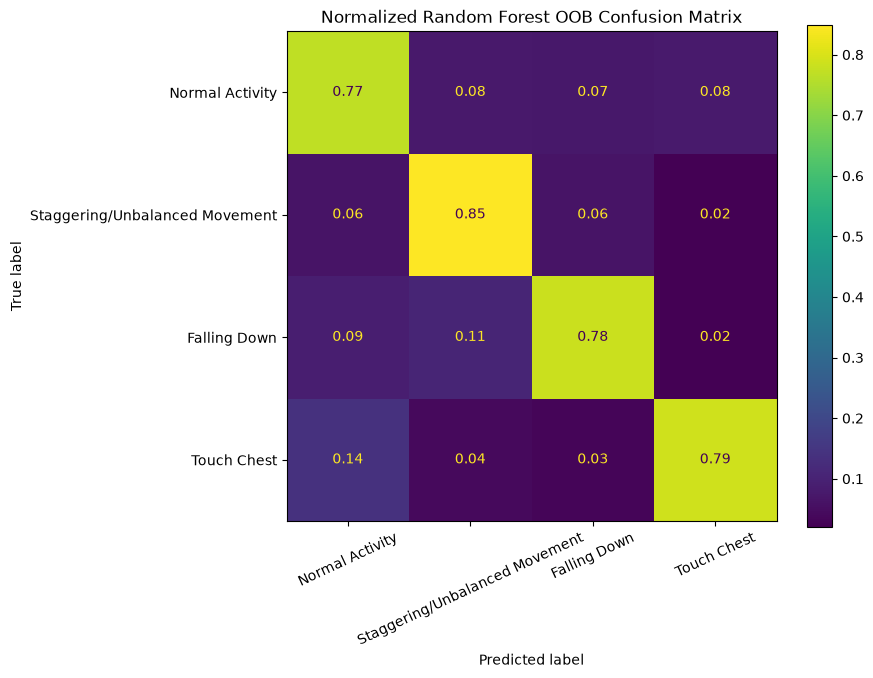

In [60]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_order = [
    "Normal Activity",
    "Staggering/Unbalanced Movement",
    "Falling Down",
    "Touch Chest"
]

oob_cm_normalized = confusion_matrix(
    y_train,
    oob_pred,
    labels=class_order,
    normalize="true"
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=oob_cm_normalized,
    display_labels=class_order
)

fig, ax = plt.subplots(figsize=(9, 7))

disp.plot(
    ax=ax,
    values_format=".2f",
    xticks_rotation=25
)

plt.title("Normalized Random Forest OOB Confusion Matrix")
plt.tight_layout()
plt.show()